# Surviving the tail: an extreme-value laboratory

In our previous project, [Quant-RMT-FatTails](https://github.com/MarcoGaloppo/Quant-RMT-FatTails), we built the whole RMT apparatus and, on S&P data, cleaned SCM five different ways and scored them out of sample. We found that RIE won. Then we re-scored the very same P&L streams on the *tail* instead of on the variance. This simple change destroyed the ranking. Indeed, we saw that whilst RIE won on volatility, it was the Ledoit-Wolf method who won on expected shortfall (ES), and finally clipping turned up as the winner with respect to maximum drawdown. Additionally, RIE had the *worst* ES-to-volatility ratio of the lot. To wit, the harder one squeezes the second moment the more of what remains gets concentrated into the tail. This can be a problem. 

Those results were simply a *measurement* problem. Indeed, [Quant-RMT-FatTails](https://github.com/MarcoGaloppo/Quant-RMT-FatTails) was built around RMT and SCM. As such, every score effectively probed the second moment of a distribution. This, however, in a market where $R_4$ never converges and one day owns 12% of the fourth-moment sum. 

Therefore, in this notebook we ask the obvious next question: **can we measure a tail at all?** To do so, before trying on real data, we will of course run some experiments.

Spoilers, the answer to our previous question is going to be: "yes, but badly, and you must know how badly". 

Our master plan:

**The starting line (Part 0).** We find out that the empirical expected shortfall is a liar. The rest follows.

**How much data do you need? (Parts 1-2).** The CLT can be very *slow*. We measure how slow with Taleb's $\kappa$, as a direct probe of preasymptotics. Then, we go looking for where a tail even begins. 

**The two roads of EVT (Parts 3-4).** We will look at block maxima and generalized extreme values (GEV), as weel as peaks-over-threshold (POV) and the
generalized pareto distribution (GPD). Both are limit theorems, so both come with the same question: how fast? We will find that EVT converges beautifully for power laws and appallingly for thin ones. It could be worse.

**We do not know $\alpha$ (Parts 5-6).** The tail exponent has a sampling distribution (as everything does). However, this is skewed, and the bias points as per usual in the worst possible direction. Then the part that cannot be estimated at all: how much of the truth lives beyond the largest thing we have ever seen? Go figure as they say.

**Using our toolkit (Parts 7-8).** We present a shoot-out between six risk estimators, scored out of sample against backtests. And finally sizing: given what we now know we do not know, how much can we bet and still be here next year?

Everything runs on `evt_lab.py` (numpy + scipy, seeded). Central companion text: Taleb, *Statistical Consequences of Fat Tails*; for the EVT machinery, Embrechts, Kl\"uppelberg & Mikosch, *Modelling Extremal Events*, and Coles, *An Introduction to Statistical Modeling of Extreme Values*.

Finally, before we start. A note on our convention. **Losses are positive.** A return of $-3\%$ is a loss of $0.03$, every VaR and ES here is a positive number on the loss scale, and $p$ is always the *tail probability* ($0.01$), never the confidence level. Tail exponents obey $\alpha = 1/\xi$, so a cubic tail is
$\alpha = 3$, $\xi = 1/3$.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from evt_lab import (
    sample_pareto, sample_student, sample_stable, sample_lognormal, sample_gpd, sample_gev,
    variance_preserving_mixture, stochvol_returns, garch_returns, garch_kesten_alpha,
    t_copula_uniforms,
    mad, mad_over_std, max_to_sum_ratio, kappa_mc, kappa_bootstrap,
    kurtosis_under_aggregation, survival_empirical, local_alpha, excess_conditional_ratio,
    block_maxima, fit_gev, gev_return_level, gumbel_norming,
    mean_excess, exceedances, fit_gpd, fit_gpd_pwm, gpd_profile_ci, threshold_stability,
    pot_var_es,
    hill, hill_plot, pickands, dedh_moment, loglog_ols_alpha, pareto_mle_alpha,
    alpha_hat_moments,
    pareto_mean_above, expected_max_pareto, hidden_mean_fraction, dual_transform,
    dual_inverse, shadow_mean, quantile_contribution,
    var_es_empirical, var_es_gaussian, var_es_student, var_es_ewma, var_es_gpd,
    es_var_ratio, alpha_from_es_var_ratio, es_sigma_ratio,
    extremal_index, decluster, stationary_bootstrap,
    drawdown, max_drawdown, growth_rate, kelly_fraction, kelly_empirical, barbell,
    leverage_for_es, simulate_wealth, ruin_probability,
    var_hits, kupiec_pof, christoffersen_independence, christoffersen_cc, acerbi_szekely_z2,
)

SEED = 20260907
rng = np.random.default_rng(SEED)
pd.set_option("display.width", 200)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11,
    "legend.frameon": False,
})
C0, C1, C2, C3, C4 = "C0", "C1", "C2", "C3", "C4"


def loglog_survival(ax, x, label=None, color=C0, **kw):
    # Zipf plot: a power-law tail is a straight line of slope -alpha.
    xs, s = survival_empirical(np.abs(np.asarray(x, float)))
    ax.loglog(xs, s, lw=1.4, color=color, label=label, **kw)


def std_to(x, mu=0.0004, sig=0.012):
    # Force a stream to EXACTLY these sample moments, so comparisons are like for like.
    x = np.asarray(x, float)
    return mu + sig * (x - x.mean()) / x.std()


def maxima(gen, reps, n, seed, chunk=2_000_000):
    # Max of n draws, reps times, without ever allocating reps*n at once.
    r = np.random.default_rng(seed)
    out = np.empty(reps)
    per = max(1, chunk // n)
    i = 0
    while i < reps:
        j = min(reps, i + per)
        out[i:j] = gen((j - i, n), r).max(axis=1)
        i = j
    return out

## Part 0 — The empirical expected shortfall is (also) a compulsive liar

In [Quant-RMT-FatTails](https://github.com/MarcoGaloppo/Quant-RMT-FatTails) the simulation lab took the in-sample covariance matrix to court for lying. Of course, we won that tace. Indee, at $q = N/T$, the min-variance portfolio believes a volatility $\sqrt{1-q}$ times the truth and delivers $1/\sqrt{1-q}$ times it. Wrong twice, in opposite directions.

We now start another trial, with the same accusation against the object people would naively reach for when they want a tailnumber, namely the **historical expected shortfall**:

$$\widehat{\mathrm{ES}}_p \;=\; \frac{1}{\lceil pn \rceil}\sum_{i=1}^{\lceil pn\rceil} X_{(i)}\,,$$

i.e., the average of the worst $\lceil pn \rceil$ observations. Note, that in a fat-tail situation this is clearly bounded above by the worst thing that has already happened. Just saying. it is clearly suspiscious. 

Let us then set an experiment to settle the case. First, we pick a truth we can score against. Then, we take losses $X \sim \mathrm{Pareto}(\alpha)$ with $x_m = 1$, so $P(X > x) = x^{-\alpha}$. Hence, we can write for the value at risk (VaR) and the ES

$$\mathrm{VaR}_p = p^{-1/\alpha}\,, \qquad \mathrm{ES}_p = \frac{\alpha}{\alpha-1}\,\mathrm{VaR}_p\, .$$

For example, with the cubic law $\alpha = 3$ and $p = 1\%$ this is $\mathrm{VaR}_{99} = 4.642$ and $\mathrm{ES}_{99} = 6.962$. Now let us go and estimate it.

In [2]:
alpha, p = 3.0, 0.01
true_var = p ** (-1 / alpha)
true_es = alpha / (alpha - 1) * true_var

rows = []
for n in (250, 500, 1000, 2000, 10000):
    est = np.array([var_es_empirical(sample_pareto(alpha, n, np.random.default_rng(s)), p)["es"]
                    for s in range(4000)])
    rows.append({"n": n, "obs in the tail": int(np.ceil(p * n)),
                 "mean ES-hat": est.mean(), "median ES-hat": np.median(est),
                 "median / true": np.median(est) / true_es,
                 "P(ES-hat < true)": np.mean(est < true_es)})
print(f"truth:  VaR99 = {true_var:.4f}   ES99 = {true_es:.4f}")
pd.DataFrame(rows).set_index("n").round(3)

truth:  VaR99 = 4.6416   ES99 = 6.9624


,obs in the tail,mean ES-hat,median ES-hat,median / true,P(ES-hat < true)
n,,,,,
250,3,6.298,5.747,0.825,0.744
500,5,6.795,6.373,0.915,0.646
1000,10,6.883,6.626,0.952,0.610
2000,20,6.915,6.765,0.972,0.590
10000,100,6.948,6.911,0.993,0.549


What can I say?  I could have been a lawyer. Another net win for our case. We can see that the ES is even a worse liar than the SCM. Indeed:

**1. The estimator is clearly biased downward** At $n = 250$ (one year of daily data) the median estimate is $82.5\%$ of the truth, and it lands below the truth **74%** of the time. After eight years ($n = 2000$) it is still low $59\%$ of the time. The bias decays, but it decays slowly. Always pointing downward.

**2. The mean and the median disagree**, i.e., we are dealing with a skewed sampling distribution. Note that in this case the *typical* estimate is much worse than the average estimate, because the average is occasionally rescued by a sample that happened to contain a monster.

**3. Look at the second column.** At $n = 250$ the estimate is the mean of **three numbers**. That is not statistics. It is guessing. Three observations can disprove something. But they can ahrdly prove anything.

And now we ask: *is volatility capturing this somehow?* To find out let us hold $\sigma = 1$ fixed at one and vary only the shape.

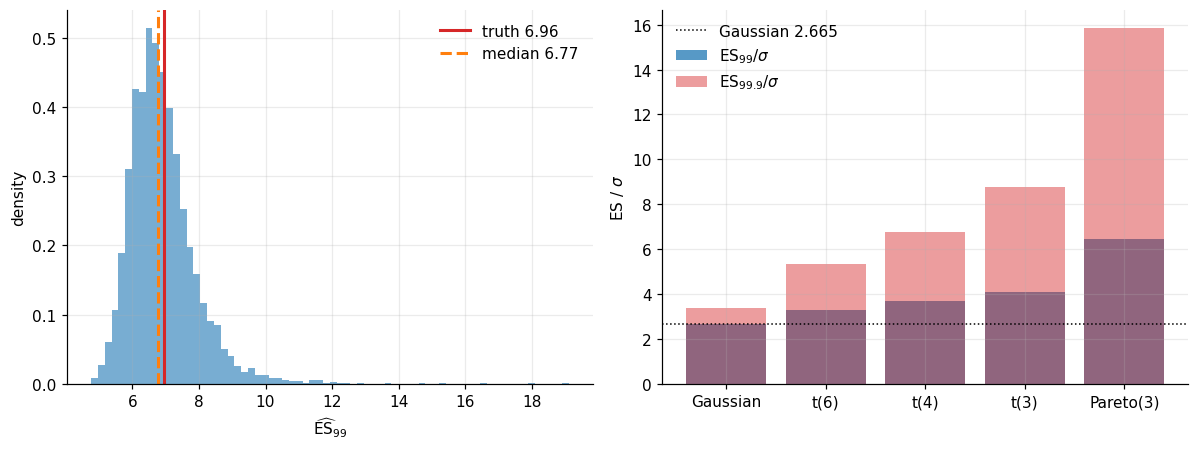

,sigma,ES99 / sigma,ES999 / sigma,MAD / STD
dist,,,,
Gaussian,0.999,2.661,3.355,0.799
t(6),1.002,3.298,5.330,0.749
t(4),0.999,3.707,6.768,0.708
t(3),0.991,4.088,8.753,0.643
Pareto(3),1.000,6.452,15.861,0.531


In [3]:
r2 = np.random.default_rng(5)
n = 500_000
sams = {"Gaussian": r2.standard_normal(n),
        "t(6)": sample_student(6., n, r2, standardize=True),
        "t(4)": sample_student(4., n, r2, standardize=True),
        "t(3)": sample_student(3., n, r2, standardize=True)}
pa = sample_pareto(3., n, r2)
sams["Pareto(3)"] = (pa - pa.mean()) / pa.std()

rows = [{"dist": k, "sigma": v.std(), "ES99 / sigma": es_sigma_ratio(v, .01),
         "ES999 / sigma": es_sigma_ratio(v, .001), "MAD / STD": mad_over_std(v)}
        for k, v in sams.items()]
tab = pd.DataFrame(rows).set_index("dist")

fig, (ax1, ax2) = plt.subplots(1, 2)
est2000 = np.array([var_es_empirical(sample_pareto(alpha, 2000, np.random.default_rng(s)), p)["es"]
                    for s in range(4000)])
ax1.hist(est2000, bins=70, color=C0, alpha=.6, density=True)
ax1.axvline(true_es, color=C3, lw=2, label=f"truth {true_es:.2f}")
ax1.axvline(np.median(est2000), color=C1, lw=2, ls="--", label=f"median {np.median(est2000):.2f}")
ax1.set(xlabel=r"$\widehat{\mathrm{ES}}_{99}$", ylabel="density")
ax1.legend()
ax2.bar(tab.index, tab["ES99 / sigma"], color=C0, alpha=.75, label=r"$\mathrm{ES}_{99}/\sigma$")
ax2.bar(tab.index, tab["ES999 / sigma"], color=C3, alpha=.45, label=r"$\mathrm{ES}_{99.9}/\sigma$")
ax2.axhline(2.665, color="k", lw=1, ls=":", label="Gaussian 2.665")
ax2.set(ylabel="ES / $\\sigma$")
ax2.legend()
plt.tight_layout(); plt.show()
tab.round(3)

The plot above shows: the $\hat{\rm{ES}}_{99}$ sampling distribution for a Pareto(3) with 4000 extraction (left panel); and the ${\rm ES}_{99}/\sigma$ and ${\rm ES}_{99.9}/\sigma$ ratios for a series of distribution. Same unit standard deviation for every distribution.

**Volatility does not capture the tail behavior. Not even close**.

Indeed, we see that $\mathrm{ES}_{99}/\sigma$ runs from $2.663$ for the Gaussian to $6.444$ for the Pareto(3), i.e., a factor of $2.4$, and at $p = 0.1\%$ from $3.37$ to $15.70$, namely a factor of $4.7$. The volatility is a *scale*. It fixes how wide the distribution is and says nothing whatsoever about its tail shape. 

Note also the fourth column. $\mathrm{MAD}/\mathrm{STD}$ falls monotonically, $0.798 \to 0.527$ (where $0.798 \sim \sqrt{2/\pi}$ i.e., the expected Gaussian value). I mean, this is just the cheapest fat-tail diagnostic in existence: it needs two moments rather than four, and it is bounded.

Now, remember that in [Quant-RMT-FatTails](https://github.com/MarcoGaloppo/Quant-RMT-FatTails) we scored portfolios on $\sigma$. Here, we can see clearly that two portfolios with identical $\sigma$ can differ by a factor of two in what they lose on a bad day and a factor of five on a very bad one. **To wit, the estimators ranking did not survive tail scoring because $\sigma$ was never a ranking of tails in the first place.**

## Part 1 — The law of medium numbers: how much data do you actually need?

The more instinctive defence to our finding is "get more data". Fine. But, how much more?

The look at this we will use Taleb's $\kappa$ (SCoFT Chapter 8). Take $M(n)$, the **mean absolute deviation** of a sum of $n$ i.i.d. draws, and define

$$\kappa(n_0, n) \;=\; 2 - \frac{\ln (n/n_0)}{\ln\!\big(M(n)/M(n_0)\big)} \,.$$

Under the CLT, $M(n) \propto \sqrt{n}$ and $\kappa = 0$. For an $\alpha$-stable, $\kappa = 2-\alpha$ exactly. In general $M(n) \propto n^{1/(2-\kappa)}$, so the standard error of a mean shrinks like $n^{(\kappa-1)/(2-\kappa)}$ rather than $n^{-1/2}$, and matching the precision of $n_G$ Gaussian observations requires

$$n \;=\; n_G^{\,\frac{2-\kappa}{2(1-\kappa)}} .$$

Just a couple of remarks on this statistics. Primo, it is built on the **first** absolute moment, so it exists when the mean does (unlike e.g., kurtosis, which requires a whooping four moments). Secondo, it carries two arguments, $n_0$ and $n$, because it is **not a constant of the distribution**. That is the whole point.

In [4]:
gens = {"Gaussian": lambda s, r: r.standard_normal(s),
        "t(4)": lambda s, r: sample_student(4., s, r),
        "t(3)": lambda s, r: sample_student(3., s, r),
        "Pareto(3)": lambda s, r: sample_pareto(3., s, r),
        "lognormal(2)": lambda s, r: sample_lognormal(2., s, r),
        "stable(1.5)": lambda s, r: sample_stable(1.5, s, r)}

rows = []
for k, g in gens.items():
    d = {"dist": k}
    for nn in (2, 30, 100):
        d[f"kappa(1,{nn})"] = kappa_mc(g, n=nn, n0=1, reps=50_000, rng=np.random.default_rng(1))
    kap = d["kappa(1,100)"]
    d["n to match 1000 Gaussian obs"] = 1000 ** ((2 - kap) / (2 * (1 - kap))) if kap < 1 else np.inf
    rows.append(d)
pd.DataFrame(rows).set_index("dist").round(3)

,"kappa(1,2)","kappa(1,30)","kappa(1,100)",n to match 1000 Gaussian obs
dist,,,,
Gaussian,-0.074,0.004,0.001,1002.051
t(4),0.200,0.120,0.096,1443.791
t(3),0.297,0.195,0.155,1885.080
Pareto(3),0.516,0.321,0.273,3666.565
lognormal(2),0.808,0.660,0.598,168562.941
stable(1.5),0.628,0.395,0.480,24305.040


A nice table which just screams: **preasymptotics**. 

What do we see? 

Clearly, **$\kappa$ decays with $n$.** The t(4) runs $0.200 \to 0.120 \to 0.096$, the t(3) $0.297 \to 0.195 \to 0.155$, the Pareto(3) $0.516 \to 0.321 \to 0.273$, the lognormal $0.808 \to 0.660 \to 0.598$. All four are crawling toward the Gaussian basin. The point is the speed at which they are getting there. We remark that such a description is not possible with just a single number, e.g., "the tail exponent". To wit, **fat-tailedness is a function of sample size, not simply a property of a distribution.**

Importantly, here we wanted to use the stable(1.5) as a control. Its $\kappa$ is *theoretically constant* at $2 - \alpha = 0.5$ for every $n$, because an $\alpha$-stable is exactly self-similar. However, our estimates read $0.628$, $0.395$, $0.480$, i.e., in the right neighbourhood, wobbling. That wobble is Monte Carlo error at $50{,}000$ replications. Now, why is it that big? Well, because we are estimating a functional of an infinite-variance variable, so our estimate of "how hard this is to estimate" is itself hard to estimate! The Gaussian row wobbles too ($-0.074$, $0.004$, $0.001$) but harmlessly, because there is nothing fat to be uncertain about.

**The last column is the strong operational statement.** To learn as much as $1000$ Gaussian observations would teach you, a t(3) needs about $1{,}900$, a Pareto(3) about $3{,}700$, and a lognormal with $\sigma = 2$ needs **168,000**. You heard it here folks, the lognormal — which has every moment finite — is by far the worst of the lot. Fat-tailedness in the sense that matters for *inference* is not the same thing as an infinite moment. It is about how much of the sum a single observation owns.

Now, to get an even better view at this.

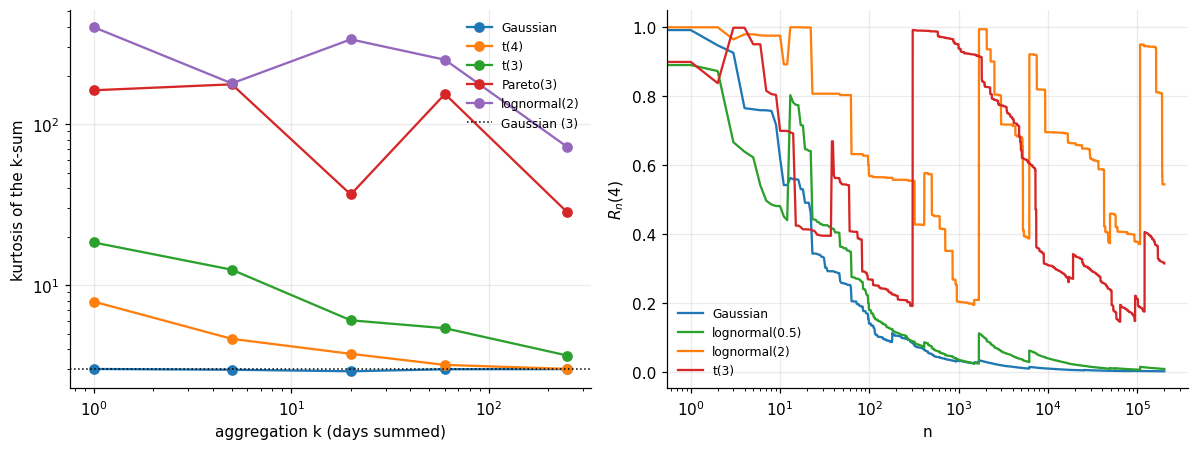

kurtosis of the k-sum: 5 samples, 2000 blocks at every k (so the ceiling never moves)


,k=1,k=5,k=20,k=60,k=250
dist,,,,,
Gaussian,3.02,2.98,2.92,3.00,3.01
t(4),7.90,4.64,3.75,3.20,3.02
t(3),18.40,12.47,6.05,5.40,3.66
Pareto(3),162.10,176.45,36.54,153.63,28.30
lognormal(2),399.24,178.81,335.46,250.71,72.05


max-to-sum R_n(p) at n = 200,000


,R(1),R(2),R(3),R(4)
dist,,,,
Gaussian,0.0000,0.0001,0.0003,0.0008
t(4),0.0003,0.0077,0.1047,0.4647
t(3),0.0004,0.0107,0.1051,0.3140
Pareto(3),0.0002,0.0056,0.0830,0.3668
lognormal(2),0.0075,0.1947,0.4243,0.5433
stable(1.5),0.0032,0.1364,0.3600,0.5254
lognormal(0.5),0.0000,0.0003,0.0018,0.0075


In [5]:
lags = [1, 5, 20, 60, 250]
BLOCKS = 2000          # the SAME number of k-sums at every lag -- see the note below

rows = []
for k, g in gens.items():
    if k == "stable(1.5)":
        continue
    v = np.mean([kurtosis_under_aggregation(g(BLOCKS * max(lags), np.random.default_rng(40 + s)),
                                            lags, blocks=BLOCKS) for s in range(5)], axis=0)
    rows.append({"dist": k, **{f"k={l}": vv for l, vv in zip(lags, v)}})
kurt = pd.DataFrame(rows).set_index("dist")

ms_gens = dict(gens)
ms_gens["lognormal(0.5)"] = lambda s, r: sample_lognormal(0.5, s, r)   # same family, mild scale
rows = [{"dist": k, **{f"R({pp})": max_to_sum_ratio(g(200_000, np.random.default_rng(9)), pp)[-1]
                       for pp in (1, 2, 3, 4)}} for k, g in ms_gens.items()]
ms = pd.DataFrame(rows).set_index("dist")

fig, (ax1, ax2) = plt.subplots(1, 2)
for k, c in zip(kurt.index, (C0, C1, C2, C3, C4)):
    ax1.loglog(lags, kurt.loc[k], "o-", color=c, label=k)
ax1.axhline(3, color="k", ls=":", lw=1, label="Gaussian (3)")
# ax1.axhline(BLOCKS, color="grey", ls="--", lw=1.2, label=f"ceiling  $b_2 \\leq m$ = {BLOCKS}")
ax1.set(xlabel="aggregation k (days summed)", ylabel="kurtosis of the k-sum")
ax1.legend(fontsize=8)
for k, c in zip(("Gaussian", "lognormal(0.5)", "lognormal(2)", "t(3)"), (C0, C2, C1, C3)):
    ax2.plot(max_to_sum_ratio(ms_gens[k](200_000, np.random.default_rng(9)), 4.0), color=c, label=k)
ax2.set(xscale="log", xlabel="n", ylabel="$R_n(4)$")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"kurtosis of the k-sum: 5 samples, {BLOCKS} blocks at every k (so the ceiling never moves)")
display(kurt.round(2))
print("max-to-sum R_n(p) at n = 200,000")
display(ms.round(4))

OK, two very nice plots and tow very cute tables. One thing at the time though. 

Let us start by discussing **kurtosis under aggregation**. Primo, we note that the sample kurtosis of $m$ numbers cannot exceed $m$ (just put
all the mass on one point and the ratio saturates at exactly $m$). Therefore, we hold the block count fixed at $m = 2000$ instead, drawing $2000k$ observations for each lag. Secondo,  we reamrk that *some of these rows have no target at all* (since the underlying distribution has infinite moment). However, a sum of finitely many infinite-fourth-moment variables still has one, at *every* $k$. Therefore these distributions will not have the kurtosis converge to anything. They cannot. Now, what do we see? 

1. **The Gaussian is flat at 3** ($3.02$, $2.98$, $2.92$, $3.00$, $3.01$), i.e., the control is working

2. **The two moderate cases descend cleanly.** To wit, t(4) runs $7.9 \to 4.6 \to 3.8 \to 3.2 \to 3.0$ and t(3) runs $18.4 \to 12.5 \to 6.1 \to 5.4 \to 3.7$. However, beware! Since the population kurtosis is infinite at every $k$, what we are watching is not a moment converging but **the body of the distribution filling in faster than the tail**, so that $2000$ blocks of a $k$-sum increasingly look Gaussian to a bounded estimator.

3. **The two extreme cases do not descend at all.** Pareto(3) gives $162 \to 176 \to 37 \to 154 \to 28$ and lognormal(2) gives $399 \to 179 \to 335 \to 251 \to 72$ — up, down, up, down. We could call this an honest picture of measuring a quantity that does not exist (Pareto) or exists at $9.2$ million and cannot
be reached (lognormal). To wit, **you get a number, it is reproducible to zero significant figures, and it is a description of whichever observation happened to be largest.**

As such, the concept of "Daily returns are fat-tailed, so work monthly", which supposesthat aggregation buys normality, simply does not work.

Now let us move on to the right-hand panel, and the second table, i.e., the **$R_n(p)$ statistics**. We do know that $R_n(p) \to 0$ **iff** $E|X|^p < \infty$. However, once again, no one has told us about preasymptotics. Look at the lognormal examples. The lognormal has **every** moment finite. Yet for lognormal(2) we see that $R_n(4) = 0.543$ at $n = 200{,}000$, which is worse than the genuinely infinite-fourth-moment $t(3)$ at $0.314$. How come? Well, for $X = e^{2Z}$ we have $X^4 = e^{8Z}$, whose squared coefficient of variation is $e^{64} - 1 \approx 6 \times 10^{27}$. The sum stops being owned by its maximum only once $\ln n \gg (4\sigma)^2 = 64$; at $n = 200{,}000$, $\ln n = 12.2$. So $R_n(4)$ *is* heading to zero and will need roughly $10^{27}$ observations to get there. It is still at $0.17$ at ten million. Instead, **lognormal(0.5)** gives $R(4) = 0.0075$ and decays essentially like a Gaussian. 

Therefore, the correct reading of $R_n(p)$ is a **usability** test, not an existence test. To wit, *is the $p$-th moment a fact about the population, or a fact about my sample?* When it stays high, every statistic resting on that moment is measuring one observation, and it makes no practical difference whether
the moment exists in theory. Note that here we have learned something new, and **updated** our interpretation with respect to [Quant-RMT-FatTails](https://github.com/MarcoGaloppo/Quant-RMT-FatTails). Practiaclly, nothing changes, but it is important nonetheless.

**Finally, the $R(1)$ column: everything is at $10^{-3}$ or below.** Means are fine. It is the higher moments that are fiction. This is the whole argument for building diagnostics out of $\mathrm{MAD}$ and $\kappa$ rather than out of $\sigma$ and kurtosis.

## Part 2 — Where does the tail actually begin?

Now, we can move to the rather convolutated question of **how hard is it to measure a tail?**. Anyone can say "the Student-t(3) has a tail exponent of 3". But *where* is that true in a data sample?

We thus define the **local tail exponent** as the running log-log slope of the survival function, i.e.,

$$\alpha_{\mathrm{loc}}(x) \;=\; -\,\frac{d \ln S(x)}{d \ln x}\,, \qquad S(x) = P(X > x)\,.$$

For an exact power law $S(x) = x^{-\alpha}$ this is the constant $\alpha$ at every $x$. For anything else it is a *function*, for which we know $\alpha_{\mathrm{loc}}(x) \to \alpha$ as $x \to \infty$. The hedge at which we can trust in convergence can be estimated by using Taleb's Karamata point (SCoFT 5.1, and the "crossover / tunnel effect" of 4.3.1). We are about to measure just that.

Note also that we use the *exact* survival functions here, so that whatever we find is a property of the distribution.

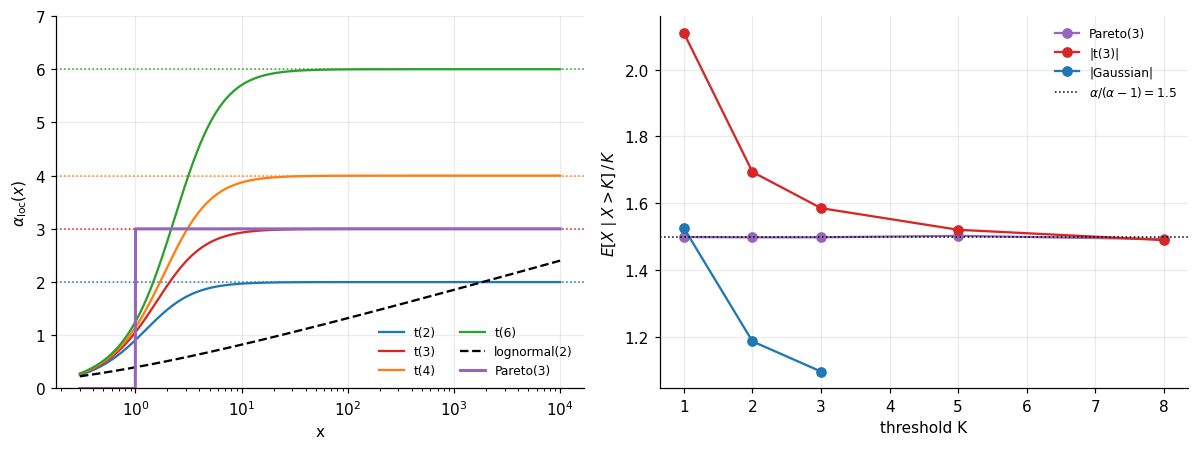

,true alpha,a_loc(1),a_loc(3),a_loc(10),a_loc(30),x* : a_loc = 0.9 alpha,S(x*),obs to see ONE
parent,,,,,,,,
t(2),2.0,0.9107,1.7227,1.9705,1.9967,3.6312,0.0341,29.3367
t(3),3.0,1.0575,2.3901,2.9300,2.9920,4.6143,0.0096,104.4335
t(4),4.0,1.1482,2.9583,3.8716,3.9852,5.4370,0.0028,360.1038
t(6),6.0,1.2539,3.8717,5.7024,5.9652,6.8374,0.0002,4158.4553


In [22]:
from scipy.stats import t as student_dist, lognorm

def loc_alpha_exact(sf, lo=0.3, hi=1e4, m=4000):
    g = np.exp(np.linspace(np.log(lo), np.log(hi), m))
    return local_alpha(g, sf(g), bins=None)

rows = []
for nu in (2., 3., 4., 6.):
    x, a = loc_alpha_exact(lambda g: student_dist.sf(g, nu))
    i = np.argmax(a >= 0.9 * nu)
    xk = x[i]; sk = float(student_dist.sf(xk, nu))
    rows.append({"parent": f"t({nu:.0f})", "true alpha": nu,
                 "a_loc(1)": float(np.interp(1, x, a)), "a_loc(3)": float(np.interp(3, x, a)),
                 "a_loc(10)": float(np.interp(10, x, a)), "a_loc(30)": float(np.interp(30, x, a)),
                 "x* : a_loc = 0.9 alpha": xk, "S(x*)": sk, "obs to see ONE": 1 / sk})
tab2 = pd.DataFrame(rows).set_index("parent")

fig, (ax1, ax2) = plt.subplots(1, 2)
for nu, c in zip((2., 3., 4., 6.), (C0, C3, C1, C2)):
    x, a = loc_alpha_exact(lambda g: student_dist.sf(g, nu))
    ax1.semilogx(x, a, color=c, label=f"t({nu:.0f})")
    ax1.axhline(nu, color=c, ls=":", lw=1)
x, a = loc_alpha_exact(lambda g: lognorm.sf(g, 2.0))
ax1.semilogx(x, a, color="k", ls="--", label="lognormal(2)")
x, a = loc_alpha_exact(lambda g: np.where(g >= 1, g ** -3., 1.))
ax1.semilogx(x, a, color=C4, lw=2, label="Pareto(3)")
ax1.set(xlabel="x", ylabel=r"$\alpha_{\rm loc}(x)$", ylim=(0, 7))
ax1.legend(fontsize=8, ncol=2)

r2 = np.random.default_rng(2)
ks = [1., 2., 3., 5., 8.]
for nm, xx, c in (("Pareto(3)", sample_pareto(3., 500_000, r2), C4),
                  ("|t(3)|", np.abs(sample_student(3., 500_000, r2)), C3),
                  ("|Gaussian|", np.abs(r2.standard_normal(2_000_000)), C0)):
    ax2.plot(ks, excess_conditional_ratio(xx, ks), "o-", color=c, label=nm)
ax2.axhline(1.5, color="k", ls=":", lw=1, label=r"$\alpha/(\alpha-1) = 1.5$")
ax2.set(xlabel="threshold K", ylabel=r"$E[X \mid X>K]\,/\,K$")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
tab2.round(4)

A GREAT table and two AMAZING plots. If I may be humble. 

To begin with, we see that **a Student-t(3) does not have an exponent of 3 anywhere one is likely to have data on.** At $x = 1$ its local exponent is $1.06$. At $x = 3$ it is $2.39$. It only reaches $2.93$ at $x = 10$. The number $3$ is a statement about the far tail, and the far tail is not where data lives. Fat tails distributions have more quite days than thin tailed ones!

Then **the last two columns show how much we will not have data there.** For the exponent to be within $10\%$ of its limit we would need $x > 4.61$, where the survival probability is $0.96\%$ , i.e., roughly **one observation in 104** even qualifies as being in the converged region. To *estimate* an exponent from that region we want, say, a hundred such points, which would translate to $10^4$ observations. In other words, forty years of daily data. And that is the
friendly case. For a t(6) you need one observation in $4158$ before the exponent has converged. A hundred of those is $4 \times 10^5$ days, or about sixteen centuries.

Additionally: (i) **The lognormal never converges at all.** Its local exponent is $0.40$ at $x=1$, $1.32$ at $x=100$, and still only $2.40$ at $x = 10^4$. It will keep growing as $\alpha_{\mathrm{loc}} \approx \ln(x)/\sigma^2$ for a lognormal. On any finite window it looks exactly like a power law with whatever exponent that window happens to imply. (ii)  **The Pareto(3) is flat at 3.** That is what an actual power law looks like, and nothing else in this figure resembles it.

The plot to the right shows the same situation in units of $E[X \mid X>K]/K$, i.e., "how bad, given that it is bad". For a Pareto it is the constant $\alpha/(\alpha-1) = 1.5$. i.e., there is no scale, conditioning on a disaster tells you the disaster is $50\%$ worse than the threshold, at
every threshold (very bad). The Gaussian decays toward $1$, i.e., conditioning tells you the value is *just* over the line (very good). And $|t(3)|$ starts at $2.11$ and drifts *down* to $1.51$, arriving at the Pareto answer only around $K = 8$, which is another way of drawing exactly the same preasymptotic creep.

**The takeaway message?** "Is this a power law?" is the wrong question. A better question is "over what range, and do I have data there?". With our luck, generally the answer is no.

## Part 3 — EVT road one: block maxima, and how slowly a Gaussian becomes a Gumbel

Thankfully, when working with extreme values we can rely on EVT. In EVT, there is a genuine limit theorem for extremes (lovely). This is the **Fisher-Tippett-Gnedenko**, namely, if the maximum $M_n$ of $n$ i.i.d. draws converges to anything at all after affine rescaling, i.e., if

$$P\!\left(\frac{M_n - b_n}{a_n} \le z\right) \longrightarrow G(z)$$

for some non-degenerate $G$, then $G$ must be the **generalised extreme value** (GEV) law

$$G(z) = \exp\!\left\{-\left[1 + \xi\left(\tfrac{z-\mu}{\sigma}\right)\right]^{-1/\xi}\right\},$$

whatever the parent distribution was. Three parameters, and the *sign of $\xi$ alone* selects the domain of attraction: $\xi > 0$ Fréchet (heavy, $\alpha = 1/\xi$), $\xi = 0$ Gumbel (thin, exponential-ish), $\xi < 0$ Weibull (bounded above). This is the CLT of extremes, and just like the CLT of averages it says nothing about *how fast* the convergence is. We should ask, probably.

However, let us first check that it works.

In [7]:
parents = {"Pareto(3)": (lambda s, r: sample_pareto(3., s, r), 1/3),
           "t(3)": (lambda s, r: sample_student(3., s, r), 1/3),
           "t(6)": (lambda s, r: sample_student(6., s, r), 1/6),
           "Gaussian": (lambda s, r: r.standard_normal(s), 0.),
           "Exponential": (lambda s, r: r.exponential(1., s), 0.),
           "Uniform": (lambda s, r: r.random(s), -1.)}
rows = []
for k, (g, th) in parents.items():
    m = block_maxima(g(1_000_000, np.random.default_rng(4)), 250)
    xi, mu, sg = fit_gev(m)
    rows.append({"parent": k, "xi-hat (blocks of 250)": xi, "theory xi": th,
                 "domain read off": "Frechet" if xi > 0.05 else ("Weibull" if xi < -0.05 else "Gumbel"),
                 "truth": "Frechet" if th > 0 else ("Weibull" if th < 0 else "Gumbel")})
pd.DataFrame(rows).set_index("parent").round(4)

,xi-hat (blocks of 250),theory xi,domain read off,truth
parent,,,,
Pareto(3),0.3487,0.3333,Frechet,Frechet
t(3),0.3078,0.3333,Frechet,Frechet
t(6),0.1248,0.1667,Frechet,Frechet
Gaussian,-0.0949,0.0000,Weibull,Gumbel
Exponential,0.0038,0.0000,Gumbel,Gumbel
Uniform,-1.0086,-1.0000,Weibull,Weibull


Well, five out of six we got them right. The Pareto lands on $0.3487$ against a theoretical $1/3$, the t(3) on $0.3078$, the t(6) on $0.1248$ against $1/6$, the exponential on $0.0038$, the uniform on $-1.009$ against $-1$. Every domain of attraction is read off correctly from the sign of $\hat\xi$ alone. The theorem works.

**And then there is the Gaussian, which reads $\hat\xi = -0.095$: Weibull.** Bounded above. Which is false, of course. With blocks of 250 days, a
full trading year, and a million observations to build them from, the fitted shape says the wrong thing. Liar.

This is not a bug sadly. It is the convergence rate at work.

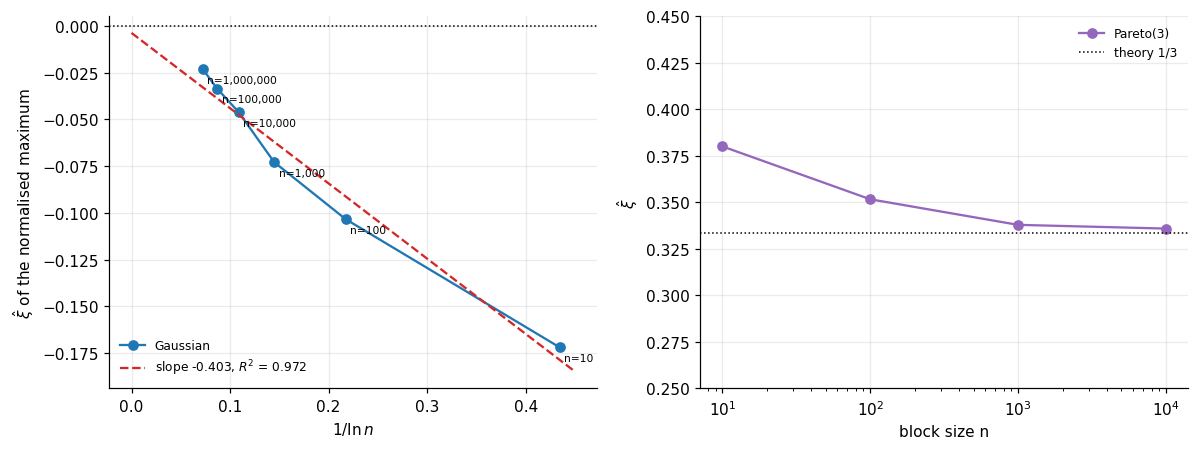

Gaussian


,1/ln n,xi-hat (Gaussian)
n,,
10,0.4343,-0.1719
100,0.2171,-0.1033
1000,0.1448,-0.0728
10000,0.1086,-0.0460
100000,0.0869,-0.0335
1000000,0.0724,-0.0231


Pareto(3)


,xi-hat (Pareto(3)),theory
n,,
10,0.3800,0.3333
100,0.3516,0.3333
1000,0.3379,0.3333
10000,0.3359,0.3333


In [23]:
rows = []
for n in (10, 100, 1000, 10_000, 100_000, 1_000_000):
    a, b = gumbel_norming(n)
    m = maxima(lambda s, r: r.standard_normal(s), 4000, n, 6)
    xi, _, _ = fit_gev((m - b) / a)
    rows.append({"n": n, "1/ln n": 1 / np.log(n), "xi-hat (Gaussian)": xi})
gg = pd.DataFrame(rows).set_index("n")

pareto_rows = []
for n in (10, 100, 1000, 10_000):
    m = maxima(lambda s, r: sample_pareto(3., s, r), 4000, n, 6)
    xi, _, _ = fit_gev(m / n ** (1 / 3.))
    pareto_rows.append({"n": n, "xi-hat (Pareto(3))": xi, "theory": 1 / 3})

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(gg["1/ln n"], gg["xi-hat (Gaussian)"], "o-", color=C0, label="Gaussian")
bfit = np.polyfit(gg["1/ln n"], gg["xi-hat (Gaussian)"], 1)
xs = np.linspace(0, 0.45, 10)
ax1.plot(xs, np.polyval(bfit, xs), ls="--", color=C3,
         label=f"slope {bfit[0]:.3f}, $R^2$ = {np.corrcoef(gg['1/ln n'], gg['xi-hat (Gaussian)'])[0,1]**2:.3f}")
ax1.axhline(0, color="k", lw=1, ls=":")
ax1.set(xlabel=r"$1/\ln n$", ylabel=r"$\hat\xi$ of the normalised maximum")
for n in gg.index:
    ax1.annotate(f"n={n:,}", (gg.loc[n, "1/ln n"], gg.loc[n, "xi-hat (Gaussian)"]),
                 fontsize=7, xytext=(3, -9), textcoords="offset points")
ax1.legend(fontsize=8)
pr = pd.DataFrame(pareto_rows).set_index("n")
ax2.semilogx(pr.index, pr["xi-hat (Pareto(3))"], "o-", color=C4, label="Pareto(3)")
ax2.axhline(1/3, color="k", ls=":", lw=1, label="theory 1/3")
ax2.set(xlabel="block size n", ylabel=r"$\hat\xi$", ylim=(0.25, 0.45))
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Gaussian"); display(gg.round(4))
print("Pareto(3)"); display(pr.round(4))

From the plot we can see that **the Gaussian converges to a Gumbel at $\ln n$ speed, whilst Pareto gets to Frechet fast.**


Indeed, looking at the left panel we find **a straight line in $1/\ln n$, $R^2 = 0.97$.** That is the classical rate, and it is tragic. At $n = 10^6$ the normalised Gaussian maximum still fits at $\hat\xi = -0.023$; to get to $-0.01$ we would need something like $n = 10^{14}$. The Pareto, meanwhile, is at $0.352$ by $n = 100$ and $0.336$ by $n=1000$.

**Therefore, EVT's own asymptotics are slow for thin tails and fast for heavy ones.** A (partially) good news! For once! La Dea Fortuna smiled to us today. However, we must neware her gifts. Indeed, a fitted $\hat\xi$ near zero, or slightly negative, is *not* evidence of a thin tail. It is equally consistent with a thin tail correctly identified and with a heavy tail we have not looked far enough into. **To wit, absence of a detected tail is not detection of an absent tail.**

One more thing before we leave block maxima, since it is really important. If we consider the **return level**

$$z_T \;=\; \mu - \frac{\sigma}{\xi}\left[1 - \left(-\ln(1 - 1/T)\right)^{-\xi}\right]$$

i.e., "the level exceeded by one block maximum every $T$ blocks" (e.g., the hundred-year flood) we see that it is an extrapolation, and $\xi$ sits in an exponent.

In [9]:
rows = []
for xi in (0.25, 0.30, 1/3, 0.36, 0.40):
    rows.append({"xi": round(xi, 4), "alpha = 1/xi": 1 / xi,
                 "z(T=10)": gev_return_level(xi, 1., 1., 10),
                 "z(T=100)": gev_return_level(xi, 1., 1., 100),
                 "z(T=1000)": gev_return_level(xi, 1., 1., 1000)})
d = pd.DataFrame(rows).set_index("xi")
d["z(1000) relative to xi=1/3"] = d["z(T=1000)"] / d.loc[0.3333, "z(T=1000)"]
d.round(3)

,alpha = 1/xi,z(T=10),z(T=100),z(T=1000),z(1000) relative to xi=1/3
xi,,,,,
0.2500,4.000,4.021,9.633,19.491,0.696
0.3000,3.333,4.214,10.917,24.140,0.862
0.3333,3.000,4.352,11.901,27.995,1.000
0.3600,2.778,4.467,12.774,31.612,1.129
0.4000,2.500,4.650,14.242,38.114,1.361


Indeed, across a range of $\alpha$ that no estimator in this notebook till now could tell apart on — $2.5$ to $4.0$, which we will shortly see is *narrower* than the sampling error on 20,000 observations — the thousand-block return level moves from $0.70\times$ to $1.36\times$ its central value. **A factor of
two only!**

The lesson is that quoting one without an interval on $\xi$ is a category error, and quoting one with a *symmetric* interval on $\xi$ is still wrong,
because the map is convex. 

## Part 4 — EVT road two: peaks over threshold, and the Hill plot

It is clear that when using block maxima we throw away data, e.g., 250 observations go in, one comes out. Instead, **peaks over threshold** (POT) keeps
every exceedance, and has its own limit theorem too! With another gracious name.

**Pickands-Balkema-de Haan**: for a distribution in *any* domain of attraction, the conditional
excess distribution above a high enough threshold converges to the generalised Pareto (GPD),

$$P(X - u \le y \mid X > u) \;\longrightarrow\; 1 - \left(1 + \frac{\xi y}{\beta}\right)^{-1/\xi} \,,$$

with the *same* $\xi$ as the GEV. To wit, this is the licence for fitting a parametric tail to a sample whose parent we do not know. As per usual though, we must ask. What does one mean by "high enough"?

In this case, the classical diagnostic is the **mean excess function**. For a GPD tail,

$$e(u) = E[X - u \mid X > u] = \frac{\beta + \xi u}{1 - \xi}\,,$$

which is **linear in $u$** with slope $\xi/(1-\xi)$. So: find where the plot goes straight, start there. Upward slope means heavy, flat means exponential, downward means a finite endpoint. 

Together with this we will also look at a **Hill's plot**. The idea is the following. Suppose that above some level $u$ the tail really is Pareto, namely
$P(X > x) = (x/u)^{-\alpha}$ for $x > u$. Then $\ln (X/u)$ is exponentially distributed with rate $\alpha$, and the maximum-likelihood estimate of the rate of an exponential is simply the reciprocal of the sample mean. So, ordering our data as $X_{(1)} \ge X_{(2)} \ge \dots \ge X_{(n)}$, keeping the largest $k$ of them and using the next one down, $X_{(k+1)}$, as the threshold, we get

$$\hat\alpha_{k,n} \;=\; \left[\frac{1}{k}\sum_{i=1}^{k} \ln X_{(i)} \;-\; \ln X_{(k+1)}\right]^{-1}\,.$$

To wit, the **Hill estimator** is nothing more exotic than the Pareto MLE applied to whatever we have decided to call the tail. Its asymptotic standard error is pleasingly simple (if the variance exist),

$$\mathrm{se}(\hat\alpha) \;=\; \frac{\alpha}{\sqrt{k}} \, ,$$

and note what that expression says: precision is bought with $k$, and with $k$ alone. The other $n - k$ observations contribute *exactly nothing*. We are not estimating a tail exponent from our sample, we are estimating it from the handful of points we nominated.

Now, the problem. We do not know $u$ — and here choosing $u$ **is** choosing $k$, since the threshold is literally $X_{(k+1)}$. So the mean-excess dial and the Hill dial are the same dial, seen from two sides. Now, note that a large $k$ reaches down into the *body* of the distribution, where the tail is not Pareto at all (Part 2 spent its whole length on exactly this), so the estimate is biased. A small $k$ stays honestly out in the tail, but by then there is almost no data left and $\alpha/\sqrt{k}$ blows up.

Hence, we compute $\hat\alpha_{k,n}$ for *every* $k$ and plot the whole lot against $k$. That is the **Hill plot**. What we are hoping to see is a **plateau**: a stretch of $k$ over which the answer simply does not depend on $k$, which is what a genuine power law would hand us. Whether seeing one is enough to *conclude* anything is a rather different question. Let us go and look.

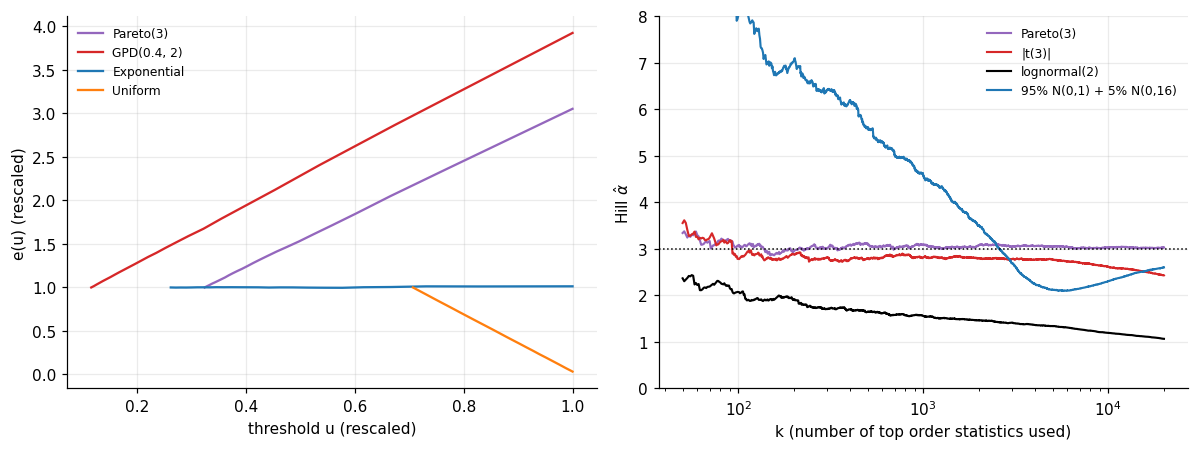

,measured slope,theory xi/(1-xi),xi
parent,,,
Pareto(3),0.4935,0.5000,0.3333
"GPD(0.4, 2)",0.6748,0.6667,0.4000
Exponential,0.0050,0.0000,0.0000
Uniform,-0.4999,-0.5000,-1.0000


In [24]:
r = np.random.default_rng(8)
cases = [("Pareto(3)", lambda s: sample_pareto(3., s, r), 1/3, C4),
         ("GPD(0.4, 2)", lambda s: sample_gpd(.4, 2., s, r), .4, C3),
         ("Exponential", lambda s: r.exponential(1., s), 0., C0),
         ("Uniform", lambda s: r.random(s), -1., C1)]
fig, (ax1, ax2) = plt.subplots(1, 2)
rows = []
for nm, g, xi, c in cases:
    x = g(300_000)
    u, e, se, nn = mean_excess(x, np.quantile(x, np.linspace(.70, .99, 25)))
    ax1.plot(u / u.max(), e / e[0], "-", color=c, label=nm)
    uu, ee, _, _ = mean_excess(x, np.quantile(x, [.80, .90, .95, .98]))
    rows.append({"parent": nm, "measured slope": np.polyfit(uu, ee, 1)[0],
                 "theory xi/(1-xi)": xi / (1 - xi), "xi": xi})
ax1.set(xlabel="threshold u (rescaled)", ylabel="e(u) (rescaled)")
ax1.legend(fontsize=8)

for nm, g, c in (("Pareto(3)", lambda s: sample_pareto(3., s, r), C4),
                 ("|t(3)|", lambda s: np.abs(sample_student(3., s, r)), C3),
                 ("lognormal(2)", lambda s: sample_lognormal(2., s, r), "k"),
                 ("95% N(0,1) + 5% N(0,16)", lambda s: np.abs(
                     r.standard_normal(s) * np.where(r.random(s) < .05, 4., 1.)), C0)):
    x = g(200_000)
    k, a, se = hill_plot(x, 50, 20_000)
    ax2.semilogx(k, a, color=c, lw=1.4, label=nm)
ax2.axhline(3, color="k", ls=":", lw=1)
ax2.set(xlabel="k (number of top order statistics used)", ylabel=r"Hill $\hat\alpha$",
        ylim=(0, 8))
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index("parent").round(4)

The left panel and the table have no surprises for us. Simply put, the mean-excess slopes match theory: $+0.494$ against $+0.500$ for the Pareto(3), $+0.675$ against $+0.667$ for the GPD(0.4), +$0.005$ against $0$ for the exponential, against $-0.500$ for the uniform. **The diagnostic works well!** Good. 

**However...**

The right panel is where la Fortuna stops smiling at us. Let us try to read the Hill plot **right to left**. Then we find first large $k$, which 
uses many order statistics, so it is precise and contaminated by the body, and then small $k$ which is unbiased and hopelessly noisy. What people look for is a *plateau* to estimate the tail index. This is a problem. To wit:

- **Pareto(3)**: flat at $3$ across two decades of $k$. A good plateau if I ever saw one.
- **$|t(3)|$**: drifts, and only approaches $3$ at the smallest $k$.
- **lognormal(2)**: a smooth, confident, entirely spurious curve. Pick $k$ and it will hand us an exponent between $1$ and $2$. There is no power law here at all.
- **the 95/5 normal mixture**: two thin-tailed Gaussians, and it shows a plausible shoulder over a decent stretch of $k$. There is no power law here either.

We could conclude by saying **a plateau is necessary evidence of a power law and never sufficient.**

So let us be more careful with it. We now fit the GPD at many thresholds and look at the *stability*. When the model holds, $\hat\xi$ should be flat above the right threshold and the modified scale $\beta^* = \beta - \xi u$ flat too. We do it on a $|t(3)|$ sample of $20{,}000$ (eighty years of daily data), and over 200 independent draws.

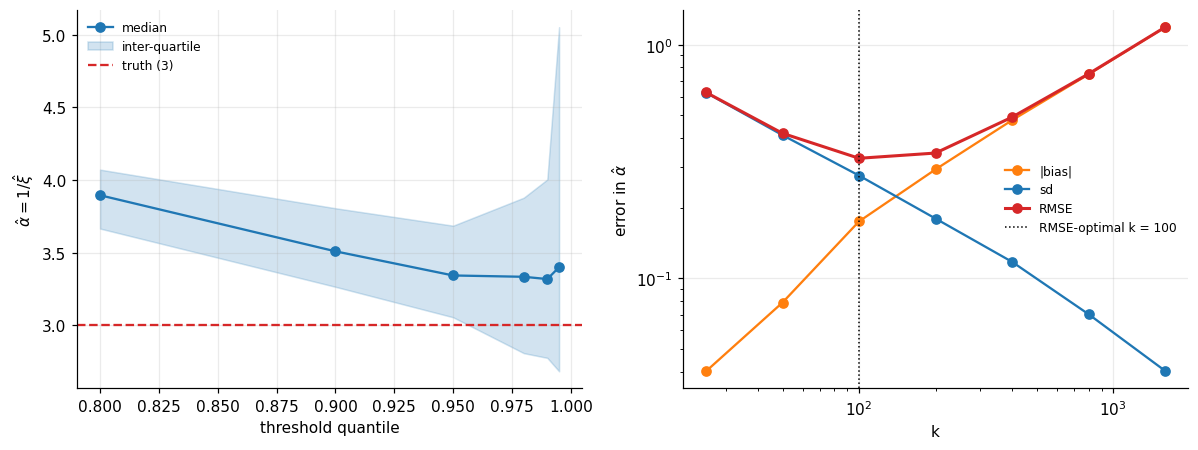

GPD threshold stability (200 draws)


,n exceedances,median alpha-hat,q25,q75,P(alpha-hat > 4),P(alpha-hat < 2.5)
threshold quantile,,,,,,
0.800,3999,3.895,3.666,4.072,0.345,0.000
0.900,1999,3.510,3.265,3.806,0.145,0.000
0.950,1000,3.343,3.056,3.686,0.120,0.000
0.980,400,3.334,2.809,3.879,0.195,0.085
0.990,200,3.319,2.776,4.004,0.250,0.140
0.995,100,3.400,2.684,5.052,0.390,0.190


Hill bias-variance (400 draws)


,mean,bias,sd,RMSE
k,,,,
25,3.040,0.040,0.624,0.625
50,2.921,-0.079,0.410,0.418
100,2.825,-0.175,0.276,0.327
200,2.707,-0.293,0.180,0.344
400,2.525,-0.475,0.118,0.490
800,2.254,-0.746,0.070,0.750
1600,1.813,-1.187,0.040,1.188


In [25]:
qs = [.80, .90, .95, .98, .99, .995]
acc = {q: [] for q in qs}
for s in range(200):
    x = np.abs(sample_student(3., 20_000, np.random.default_rng(6000 + s)))
    for q in qs:
        u = float(np.quantile(x, q)); y = x[x > u] - u
        if y.size >= 30:
            xi, _ = fit_gpd(y)
            acc[q].append(1 / xi if xi > 0 else np.inf)
rows = []
for q in qs:
    a = np.array(acc[q])
    rows.append({"threshold quantile": q, "n exceedances": int(20_000 * (1 - q)),
                 "median alpha-hat": np.median(a), "q25": np.percentile(a, 25),
                 "q75": np.percentile(a, 75), "P(alpha-hat > 4)": np.mean(a > 4),
                 "P(alpha-hat < 2.5)": np.mean(a < 2.5)})
stab = pd.DataFrame(rows).set_index("threshold quantile")

ks = [25, 50, 100, 200, 400, 800, 1600]
res = {k: [] for k in ks}
for s in range(400):
    xx = np.abs(sample_student(3., 5_000, np.random.default_rng(3000 + s)))
    for k in ks:
        res[k].append(hill(xx, k))
bv = pd.DataFrame([{"k": k, "mean": np.mean(res[k]), "bias": np.mean(res[k]) - 3,
                    "sd": np.std(res[k]), "RMSE": np.sqrt(np.mean((np.array(res[k]) - 3) ** 2))}
                   for k in ks]).set_index("k")

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(stab.index, stab["median alpha-hat"], "o-", color=C0, label="median")
ax1.fill_between(stab.index, stab["q25"], stab["q75"], color=C0, alpha=.2, label="inter-quartile")
ax1.axhline(3, color=C3, lw=1.5, ls="--", label="truth (3)")
ax1.set(xlabel="threshold quantile", ylabel=r"$\hat\alpha = 1/\hat\xi$")
ax1.legend(fontsize=8)
ax2.plot(bv.index, np.abs(bv["bias"]), "o-", color=C1, label="|bias|")
ax2.plot(bv.index, bv["sd"], "o-", color=C0, label="sd")
ax2.plot(bv.index, bv["RMSE"], "o-", color=C3, lw=2, label="RMSE")
ax2.axvline(bv["RMSE"].idxmin(), color="k", ls=":", lw=1,
            label=f"RMSE-optimal k = {bv['RMSE'].idxmin()}")
ax2.set(xscale="log", yscale="log", xlabel="k", ylabel="error in $\\hat\\alpha$")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("GPD threshold stability (200 draws)"); display(stab.round(3))
print("Hill bias-variance (400 draws)"); display(bv.round(3))

What do we see? We see that  **the median is fine. Any single draw is not.** Simple as that. 

In the left panel of the plot we see that the median $\hat\alpha$ comes down from $3.90$ at the $80$th percentile (where it is badly contaminated by the body) and settles between $3.32$ and $3.40$ from the 95th percentile upward. Slightly high, biased but basically sensible. However, we can also look at the interquartile band. At the 99.5th percentile, where people would usually look, the middle *half* of the draws lies between $\hat\alpha = 2.68$ and $\hat\alpha = 5.05$, with $39\%$ coming out above $4$ and $19\%$ below $2.5$. To wit, **with eighty years of daily data, one honest analyst following best practice draws a tail exponent anywhere from "barely fat" to "infinite variance".** 

The right panel shows the trade-off directly between the errors creeping in the estimate. The bias grows monotonically with $k$ (from $+0.04$ at $k=25$ to $-1.19$ at $k=1600$), whilst the standard deviation falls monotonically ($0.62 \to 0.04$), and the RMSE turns out as a clean U with its floor at $k = 100$. Now. Primo, $k = 100$ out of $n = 5000$ is $2\%$ of the sample, i.e., **the tail estimate uses one observation in fifty and discards the rest.** Secondo, even at the optimum the mean estimate is $2.83$, not $3$. There is no setting of $k$ that is simultaneously honest and precise, and anyone who reports one number for $\hat\alpha$ without saying which $k$ produced it is not reporting the whole story.

## Part 5 — We just do not know $\alpha$ 

For the pure Pareto case we can do better than just simulate the distribution of estimates of  $\alpha$  because the sampling distribution is available in closed form (see Taleb, SCoFT Appendix E).

If $X_i \sim \mathrm{Pareto}(\alpha, x_m)$ then $\ln(X_i/x_m) \sim \mathrm{Exp}(\alpha)$, so $\sum_i \ln(X_i/x_m) \sim \mathrm{Gamma}(n, 1/\alpha)$, and the MLE
$\hat\alpha = n / \sum_i \ln(X_i/x_m)$ is therefore **inverse-gamma** with shape $n$ and scale $n\alpha$:

$$E[\hat\alpha] = \alpha\,\frac{n}{n-1}\,, \qquad \mathrm{SD}[\hat\alpha] = \frac{\alpha\, n}{(n-1)\sqrt{n-2}} \,.$$

We thus read directly the direction of the bias ($E[\hat\alpha] -\alpha$)! Now, since $E[\hat\alpha] > \alpha$ always, we have that **the estimator systematically reports a thinner tail than the truth.** Mai una gioia, davvero.

In [12]:
rows = []
for n in (30, 60, 250, 1000):
    est = np.array([pareto_mle_alpha(sample_pareto(3., n, np.random.default_rng(s)), xm=1.)[0]
                    for s in range(6000)])
    th = alpha_hat_moments(3., n)
    rows.append({"n": n, "MC mean": est.mean(), "theory mean": th["mean"],
                 "MC median": np.median(est), "theory median": th["median"],
                 "MC sd": est.std(), "theory sd": th["sd"],
                 "theory q05": th["q05"], "theory q95": th["q95"]})
pd.DataFrame(rows).set_index("n").round(3)

,MC mean,theory mean,MC median,theory median,MC sd,theory sd,theory q05,theory q95
n,,,,,,,,
30,3.102,3.103,3.040,3.034,0.579,0.586,2.276,4.168
60,3.053,3.051,3.022,3.017,0.400,0.401,2.456,3.762
250,3.010,3.012,3.005,3.004,0.191,0.191,2.712,3.340
1000,3.004,3.003,3.001,3.001,0.096,0.095,2.850,3.163


By checking with Monte Carlo against the theory it checks out. I mean it had too. But always better to see it.

Here, the practical reading is in the last two columns. With $n = 60$ exceedances, a perfectly specified MLE on perfectly Paretian data puts a $90\%$ interval of $[2.46, 3.76]$ around a truth of $3$. Now, sixty exceedances is what a $98$th-percentile threshold gives you on twelve years of daily data. The situation is tragic for real.

Also, because $\hat\alpha$ is inverse-gamma, its *mean* is dominated by the small-$\alpha$ draws in a way its median is not. So averaging $\hat\alpha$
across assets, or across windows, is a mistake. As such one better **pool the log-excesses, never the alphas.**

Now, why we care. $\alpha$ is not the output, that is what ES is. And ES depends on $\alpha$ through $\mathrm{ES}_p = \frac{\alpha}{\alpha-1} p^{-1/\alpha}$, which is not a gentle function. Errors in $\alpha$ propagate fast!

Let us see how fast and then pit different estimators one against the other.

In [2]:
rows = []
for a in (2.5, 2.75, 3.0, 3.25, 3.5):
    v = 0.01 ** (-1 / a)
    rows.append({"alpha": a, "VaR99": v, "ES99": a / (a - 1) * v})
d = pd.DataFrame(rows).set_index("alpha")
d["ES relative to alpha=3"] = d["ES99"] / d.loc[3.0, "ES99"]
elast = (np.log(d.loc[3.25, "ES99"]) - np.log(d.loc[2.75, "ES99"])) / (np.log(3.25) - np.log(2.75))

race = []
for name, f in [("Hill (k = 100)", lambda x: hill(x, 100)),
                ("Hill (k = 500, i.e. n/10)", lambda x: hill(x, 500)),
                ("GPD-MLE (u = q95)", lambda x: 1 / fit_gpd(
                    x[x > np.quantile(x, .95)] - np.quantile(x, .95))[0]),
                ("log-log OLS (top 5%)", lambda x: loglog_ols_alpha(x, 0.05)),
                ("log-log OLS (top 1%)", lambda x: loglog_ols_alpha(x, 0.01)),
                ("Pareto MLE (exact, uses all n)", lambda x: pareto_mle_alpha(x, xm=1.)[0])]:
    v = []
    for s in range(400):
        x = sample_pareto(3., 5_000, np.random.default_rng(3000 + s))
        try: v.append(f(x))
        except Exception: pass
    v = np.array(v); v = v[np.isfinite(v)]
    race.append({"estimator": name, "mean": v.mean(), "median": np.median(v),
                 "sd": v.std(), "RMSE": np.sqrt(np.mean((v - 3) ** 2))})
print(f"elasticity  d ln ES / d ln alpha  at alpha = 3:  {elast:.3f}")
display(d.round(3))
pd.DataFrame(race).set_index("estimator").round(3)

elasticity  d ln ES / d ln alpha  at alpha = 3:  -2.047


,VaR99,ES99,ES relative to alpha=3
alpha,,,
2.50,6.310,10.516,1.510
2.75,5.337,8.386,1.205
3.00,4.642,6.962,1.000
3.25,4.125,5.958,0.856
3.50,3.728,5.219,0.750


,mean,median,sd,RMSE
estimator,,,,
Hill (k = 100),3.030,3.010,0.301,0.303
"Hill (k = 500, i.e. n/10)",3.000,3.003,0.134,0.134
GPD-MLE (u = q95),3.372,3.107,1.244,1.298
log-log OLS (top 5%),3.069,3.053,0.254,0.264
log-log OLS (top 1%),3.219,3.140,0.577,0.617
"Pareto MLE (exact, uses all n)",2.999,2.999,0.042,0.042


**The elasticity ($\mathrm{d} \ln {\rm ES} / {\rm d} \ln \alpha$) is $-2.05$ for $\alpha = 3$**. To wit, a $10\%$ error in $\alpha$ is a $20\%$ error in $\mathrm{ES}_{99}$, in the opposite direction! Overestimating $\alpha$ (which the MLE does on average as we saw above) *underestimates* ES. Across a range
of $\alpha$ from $2.5$ to $3.5$, namely, comfortably inside the interquartile band Part 4 measured on eighty years of data, $\mathrm{ES}_{99}$ moves by a factor of two.

**Now the estimator race, run on  perfect Pareto data.** What do we see? Well

**1. Hill's textbook standard error is correct.** We should have $\mathrm{se}(\hat\alpha) = \alpha/\sqrt{k}$. At $k = 100$ that is $0.300$ and we measure $0.301$; at $k = 500$ it is $0.134$ and we measure $0.134$.

**2. More $k$ is strictly better.** The RMSE falls monotonically ($0.303 \to 0.134$, seeminlgy against the results of Part 4) simply  because on a genuine Pareto there is no body to contaminate the estimate. We thus conclude that actually **the bias-variance trade-off of Part 4 was not an instrinsic property of
the Hill estimator. It was a property of the t(3)'s Karamata crossover**, i.e. of Part 2. Of course, on real data you always have the trade-off, because real data are never Pareto all the way down.

**3. The exact MLE is seven times better than Hill (here).** Using all $5{,}000$ observations it has $\mathrm{sd} = 0.042$, matching the closed form $0.0424$ from the table above; Hill at $k = 500$ manages $0.134$. Hill is *the same MLE* applied to the top $k$ order statistics, so the entire gap is the price of throwing $90\%$ of the sample away. Willingly paid on real data, where the assumption only holds in the tail.

**4. The log-log regression loses properly.** RMSE $0.264$ at the top $5\%$ against Hill's $0.134$: twice as bad, on data generated from exactly the model it assumes. It is also biased *upward* ($3.069$), i.e. toward reporting a thinner tail.

FInally, the GPD-MLE row is the same warning as before in a different costume: RMSE $1.298$, because we asked for $\hat\alpha = 1/\hat\xi$ and a reciprocal of a noisy estimate near zero has a fat tail of its own. Report $\xi$.

Now, since we now know $\hat\alpha$ has a spread we should ask the very basic practical question of how to *state* it. Two ways.

The **Wald** interval is the standard one. Namely, take the estimate, take its standard error, and go $\pm 1.96\,\mathrm{se}$. It is symmetric by construction, and it is correct only insofar as the log-likelihood is quadratic near its maximum (equivalently, only insofar as the estimator is normally distributed. At this point do I even have to say suspiscious? It relies on asymptotic regimes...

The **profile-likelihood** interval makes no such assumption. For each candidate $\xi$, maximise the likelihood over the remaining parameter $\beta$, and keep every $\xi$ whose deviance $2\,(\ell_{\max} - \ell_{\mathrm{profile}}(\xi))$ stays under the $\chi^2_1$ critical value. If the likelihood is skewed, the interval comes out skewed with it, which is the point.

The GPD likelihood in $\xi$ *is* skewed. In particular, long to the right, because the data can always be explained by a heavier tail more easily than by a lighter one. So the two intervals should disagree, and disagree asymmetrically. The next cell measures by how much, and at what sample size it starts
to matter.

In [14]:
from scipy.stats import norm as _norm
XI = 1 / 3.
rows = []
for n in (75, 150, 500):
    cp = cw = pl = pu = wl = wu = 0
    wp, ww, asym = [], [], []
    R = 250
    for s in range(R):
        y = sample_gpd(XI, 1., n, np.random.default_rng(9000 + s))
        xi, b = fit_gpd(y)
        lo, hi = gpd_profile_ci(y, 0.95, grid=60, span=0.9)
        cp += (lo <= XI <= hi); pl += (XI < lo); pu += (XI > hi)
        wp.append(hi - lo); asym.append((hi - xi) - (xi - lo))
        se = np.sqrt((1 + xi) ** 2 / n)
        l2, h2 = xi - 1.96 * se, xi + 1.96 * se
        cw += (l2 <= XI <= h2); wl += (XI < l2); wu += (XI > h2)
        ww.append(h2 - l2)
    rows.append({"n exceedances": n, "profile coverage": cp / R,
                 "profile misses HIGH": pu / R, "profile width": np.mean(wp),
                 "profile asymmetry": np.mean(asym), "Wald coverage": cw / R,
                 "Wald misses HIGH": wu / R, "Wald width": np.mean(ww)})
pd.DataFrame(rows).set_index("n exceedances").round(4)

,profile coverage,profile misses HIGH,profile width,profile asymmetry,Wald coverage,Wald misses HIGH,Wald width
n exceedances,,,,,,,
75,0.932,0.040,0.6047,0.1317,0.896,0.088,0.5913
150,0.936,0.032,0.4043,0.0672,0.944,0.040,0.4239
500,0.940,0.020,0.2018,0.0166,0.960,0.020,0.2332


In the table above "Misses high" means the true $\xi$ was **above** the interval — the tail was heavier than the interval was willing to admit. Nominal rate: $2.5\%$.

At $n = 500$ exceedances the two are interchangeable: coverage $0.940$ against $0.960$, near-identical widths, and the profile's asymmetry has shrunk to $0.017$. To be honest with 500 exceedences we can do whatever we want truly.

At $n = 75$ they are not. The Wald interval covers $89.6\%$ instead of $95\%$. Additionally, it misses high **$8.8\%$ of the time against a nominal $2.5\%$**, while the profile interval misses high $4.0\%$ and covers $93.2\%$. The profile's upper arm is $0.132$ longer than its lower arm, namely that the data are considerably more consistent with a heavier tail than with a lighter one.

Now the very sad part. Seventy-five exceedances is not a pathological case. It is a $98$th-percentile threshold on fifteen years of daily data. **So in exactly the regime we actually work in, the standard interval understates the tail three and a half times more often than it advertises, and it does so in the one
direction that costs money.** We really should use the profile interval. 

## Part 6 — The hidden tail

So far every failure we have encountered has been an *estimation* failure, i.e., something we could in principle fix with more data or a better estimator. But there are things one cannot fix.

For a Pareto with $x_m = 1$ the expected maximum of $n$ draws is $E[M_n] = n\,B(n,\,1 - 1/\alpha) \approx \Gamma(1-1/\alpha)\, n^{1/\alpha}$, growing like
$n^{1/\alpha}$. As such, for $\alpha = 3$, ten thousand observations produce a record only about twice as large as one thousand do. Essentially, records come in slowly. Meanwhile the true mean is $\alpha/(\alpha-1)$ and the part of it living above a level $M$ is $\frac{\alpha}{\alpha-1}M^{1-\alpha}$, so the fraction of the mean sitting **beyond anything you have ever seen** is simply $M_n^{1-\alpha}$.

In [15]:
rows = [{"alpha": a, **{f"n = {n:,}": hidden_mean_fraction(a, n)
                        for n in (250, 2500, 25_000, 250_000)}}
        for a in (1.1, 1.25, 1.5, 2., 2.5, 3., 4.)]
hidden_mean = pd.DataFrame(rows).set_index("alpha")

def hidden_es(a, n, p=0.01):
    M = expected_max_pareto(a, n); v = p ** (-1 / a)
    return 1.0 if M <= v else pareto_mean_above(a, M) / (p * a / (a - 1) * v)

rows = [{"alpha": a, **{f"n = {n:,}": hidden_es(a, n) for n in (250, 2500, 25_000, 250_000)}}
        for a in (1.5, 2., 2.5, 3., 4.)]
hidden_esf = pd.DataFrame(rows).set_index("alpha")
print("share of the true MEAN beyond E[max of n]"); display(hidden_mean.round(4))
print("share of the true ES99 beyond E[max of n]"); display(hidden_esf.round(4))

share of the true MEAN beyond E[max of n]


,n = 250,"n = 2,500","n = 25,000","n = 250,000"
alpha,,,,
1.10,0.4785,0.3881,0.3148,0.2553
1.25,0.2264,0.1429,0.0901,0.0569
1.50,0.0970,0.0450,0.0209,0.0097
2.00,0.0357,0.0113,0.0036,0.0011
2.50,0.0200,0.0050,0.0013,0.0003
3.00,0.0137,0.0030,0.0006,0.0001
4.00,0.0086,0.0015,0.0003,0.0000


share of the true ES99 beyond E[max of n]


,n = 250,"n = 2,500","n = 25,000","n = 250,000"
alpha,,,,
1.5,0.4501,0.2089,0.0970,0.0450
2.0,0.3566,0.1128,0.0357,0.0113
2.5,0.3173,0.0798,0.0200,0.0050
3.0,0.2958,0.0638,0.0137,0.0030
4.0,0.2730,0.0486,0.0086,0.0015


From these tables we get a bit of the story out:

1. **For the mean, the hidden share is modest unless $\alpha$ is near 1.** At $\alpha = 3$ with $2500$ observations only $0.3\%$ of the mean is out of sight. At $\alpha = 1.5$ it is $4.5\%$. It is only at $\alpha = 1.1$ that the number becomes enormous, $39\%$ at $n = 2500$. For
equity returns at $\alpha \approx 3$, the *mean* is estimable. Fine.

2. **For expected shortfall it is a different world entirely**, because ES lives entirely in the region concerned. At $\alpha = 3$ with $250$ observations, $29.6\%$ of the true $\mathrm{ES}_{99}$ sits beyond the expected maximum. At $2500$ observations (ten years) it is still $6.4\%$, and that $6.4\%$ is *structurally invisible*. Also, notice that at $n = 250$ the hidden ES share is $27$-$45\%$ across *every* $\alpha$ from $1.5$ to $4$. To wit, even a nearly-thin tail hides a
quarter of its shortfall at one year of data.

We found the floor under Part 0's finding. The empirical ES was biased low by $18\%$ at $n=250$; roughly a third of that gap is not an estimator problem at all.

The same mechanism has a well-known consequence for concentration measures. Let us look at it.

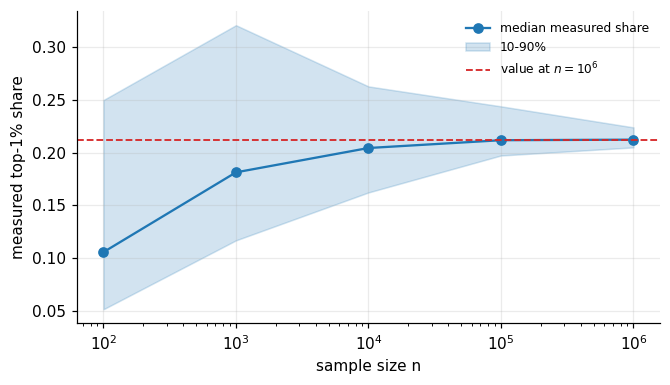

quantile contribution


,median top-1% share,q10,q90
n,,,
100,0.1060,0.0520,0.2495
1000,0.1813,0.1171,0.3202
10000,0.2043,0.1623,0.2624
100000,0.2116,0.1972,0.2436
1000000,0.2121,0.2049,0.2237


In [28]:
rows = []
for n in (100, 1000, 10_000, 100_000, 1_000_000):
    v = [quantile_contribution(sample_pareto(1.5, n, np.random.default_rng(s)), 0.01)
         for s in range(60)]
    rows.append({"n": n, "median top-1% share": np.median(v),
                 "q10": np.percentile(v, 10), "q90": np.percentile(v, 90)})
qc = pd.DataFrame(rows).set_index("n")

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.semilogx(qc.index, qc["median top-1% share"], "o-", color=C0, label="median measured share")
ax.fill_between(qc.index, qc["q10"], qc["q90"], color=C0, alpha=.2, label="10-90%")
ax.axhline(qc["median top-1% share"].iloc[-1], color=C3, ls="--", lw=1.2,
           label="value at $n=10^6$")
ax.set(xlabel="sample size n", ylabel="measured top-1% share")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("quantile contribution"); display(qc.round(4))

The plot shows **the measured top-1% share for a Pareto(1.5) climbing from $0.106$ at $n = 100$ to $0.212$ at $n = 10^6$ and then stoping.** The point is that concentration is not increasing. It's just that small samples cannot contain the observations that would produce the true share. As such we can easily say that **every measured concentration is a lower bound.**. So, for example, when the previous lab reported "the worst 1% of days carry 31% of our portfolio's variance", the honest reading was "at least 31%". 

## Part 7 — The shoot-out

This is the analogue of the previous simulation lab in [Quant-RMT-FatTails](https://github.com/MarcoGaloppo/Quant-RMT-FatTails) cleaning race. We, of course, organise it in the same way. We generate the data, we know the truth, and we score every contestant against out-of-sample data.

Six ways to produce a one-day-ahead $\mathrm{VaR}_{99}$ and $\mathrm{ES}_{99}$:

| method | what it assumes |
| :-- | :-- |
| **empirical** | nothing, and therefore cannot see past its own worst day |
| **Gaussian** | two moments are enough |
| **Student-t** | one global fat-tailed shape for body and tail together |
| **EWMA-normal** | RiskMetrics: volatility clusters, shape is Gaussian |
| **EWMA-t(5)** | volatility clusters, shape is $t(5)$ |
| **POT-GPD** | the tail above the 95th percentile is generalised Pareto |

Four data-generating processes (DGP): Gaussian (the control), standardised $t(3)$, a GARCH(1,1) with $t(6)$ innovations, and a two-regime mixture that is $N(0,1)$ $95\%$ of the time and $N(0,16)$ the rest. All four are forced to the same mean and standard deviation.

We use a rolling protocol: fit on a 1000-day window, refit every 20 days, forecast forward, and score the realised outcome. Four seeds each. The scores are (i)
**Kupiec** (is the *number* of exceptions right?),(ii)  **Christoffersen** (are they independent, or do they cluster?), and **Acerbi-Székely $Z_2$** (is the *size* right? $Z_2 > 0$ means the model promised a smaller shortfall than it delivered). Plus the raw ratio of predicted to realised ES.

This takes a few minutes. As my dear readers (and I) wait, we can go over a couple of things that popped up in the table and lines above.

**What is a GARCH(1,1)?** Generalized Autoregressive Conditional Heteroskedasticity (GARCH) is the standard way in the literature for a model of "volatility clusters". To wit, in GARCH(1,1) today's variance, $\sigma_t^2$, is built from yesterday's shock, $\varepsilon_{t-1}^2$  and yesterday's variance, $\sigma_{t-1}^2$, i.e.,

$$\sigma_t^2 \;=\; \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2, \qquad \varepsilon_t = \sigma_t z_t\,,$$

where $\omega$ is a baseline constant, $\alpha$ how violently the model reacts to shocks, and $\beta$ tells us how long past volatility takes to fade away (i.e., a decay factor).

GARC(1,1) is covariance-stationary iff $\alpha + \beta < 1$, with unconditional variance $\omega/(1-\alpha-\beta)$. Here, we use the usual equity calibration of $\alpha = 0.09$, $\beta = 0.90$, i.e., $\alpha+\beta = 0.99$. In this case, shocks persist for months. We standardize $z_t$ to $t(6)$, meaning the *conditional* distribution is already non-gaussian on top of the clustering.

**What is EWMA?** It is just exponentially weighted moving average (EWMA) of squared returns, i.e.,

$$\sigma_t^2 \;=\; (1-\lambda)\sum_{i \geq 0} \lambda^{i} r_{t-1-i}^2 \,,$$

with $\lambda = 0.94$ being the the RiskMetrics default. It is exactly a GARCH(1,1) with $\omega = 0$ and $\alpha + \beta = 1$, i.e., an IGARCH. As such, it has *no* unconditional variance to revert to. To wit, it tracks the recent past and nothing else. Here, we run it twice, with a Gaussian quantile and with a $t(5)$ one, to separate "did it get the scale right" from "did it get the shape right".

Here a note. GARCH(1,1) and EWMA here are not advocated as model to fit real data. But just as estimator and DGP. They use variances after all, and as we saw that might not be great...

In [17]:
P, W, STEP, T, NS = 0.01, 1000, 25, 4000, 3

def dgp(kind, seed):
    r = np.random.default_rng(seed)
    if kind == "Gaussian":      x = r.standard_normal(T)
    elif kind == "t(3)":        x = sample_student(3., T, r)
    elif kind == "GARCH-t(6)":  x = garch_returns(T, r, omega=1e-6, a=.09, b=.90, nu=6.)
    else:                       x = r.standard_normal(T) * np.where(r.random(T) < 0.05, 4., 1.)
    return std_to(x)

def forecast(h, m):
    if m == "empirical":     o = var_es_empirical(h, P)
    elif m == "Gaussian":    o = var_es_gaussian(h, P)
    elif m == "Student-t":   o = var_es_student(h, P)
    elif m == "EWMA-normal": o = var_es_ewma(h, P, dist="gaussian")
    elif m == "EWMA-t(5)":   o = var_es_ewma(h, P, dist="t", nu=5.)
    else:                    o = var_es_gpd(h, P, 0.95)
    return o["var"], o["es"]

METHODS = ["empirical", "Gaussian", "Student-t", "EWMA-normal", "EWMA-t(5)", "POT-GPD"]
idx = np.arange(W, T); refit = idx[(idx - W) % STEP == 0]
tables = {}
for kind in ("Gaussian", "t(3)", "GARCH-t(6)", "regime"):
    agg = {m: {k: [] for k in ("h", "z", "kp", "ip", "ra")} for m in METHODS}
    for s in range(NS):
        L = -dgp(kind, 300 + s); real = L[W:]
        for m in METHODS:
            vs, es = [], []
            for i in refit:
                try: a, b = forecast(L[i - W:i], m)
                except Exception: a, b = (vs[-1], es[-1]) if vs else (np.nan, np.nan)
                vs.append(a); es.append(b)
            v = np.repeat(vs, STEP)[:real.size]; e = np.repeat(es, STEP)[:real.size]
            ok = np.isfinite(v) & np.isfinite(e); v, e, rl = v[ok], e[ok], real[ok]
            h = (rl > v).astype(int)
            agg[m]["h"].append(h.mean())
            agg[m]["kp"].append(kupiec_pof(h, P)["pvalue"])
            agg[m]["ip"].append(christoffersen_independence(h)["pvalue"])
            agg[m]["z"].append(acerbi_szekely_z2(rl, v, e, P)["z2"])
            t = rl[rl > v]
            agg[m]["ra"].append(e[rl > v].mean() / t.mean() if t.size else np.nan)
    tables[kind] = pd.DataFrame(
        [{"method": m, "exception rate": np.mean(agg[m]["h"]),
          "Kupiec pass": np.mean(np.array(agg[m]["kp"]) > .05),
          "Indep. pass": np.mean(np.array(agg[m]["ip"]) > .05),
          "Acerbi Z2": np.mean(agg[m]["z"]),
          "predicted / realised ES": np.nanmean(agg[m]["ra"])} for m in METHODS]).set_index("method")

for kind, t in tables.items():
    print(f"=== DGP: {kind}   (target exception rate {P}; Z2 > 0 = understates ES) ===")
    display(t.round(3))

=== DGP: Gaussian   (target exception rate 0.01; Z2 > 0 = understates ES) ===


,exception rate,Kupiec pass,Indep. pass,Acerbi Z2,predicted / realised ES
method,,,,,
empirical,0.012,1.000,1.0,0.196,1.024
Gaussian,0.010,1.000,1.0,0.034,1.001
Student-t,0.010,1.000,1.0,0.015,1.009
EWMA-normal,0.015,0.333,1.0,0.573,0.984
EWMA-t(5),0.008,1.000,1.0,-0.301,1.178
POT-GPD,0.010,1.000,1.0,0.021,0.992


=== DGP: t(3)   (target exception rate 0.01; Z2 > 0 = understates ES) ===


,exception rate,Kupiec pass,Indep. pass,Acerbi Z2,predicted / realised ES
method,,,,,
empirical,0.011,1.000,1.0,0.176,0.963
Gaussian,0.014,0.667,1.0,0.833,0.756
Student-t,0.009,1.000,1.0,-0.114,1.029
EWMA-normal,0.022,0.000,1.0,1.962,0.753
EWMA-t(5),0.018,0.333,1.0,0.937,0.906
POT-GPD,0.011,1.000,1.0,0.166,0.974


=== DGP: GARCH-t(6)   (target exception rate 0.01; Z2 > 0 = understates ES) ===


,exception rate,Kupiec pass,Indep. pass,Acerbi Z2,predicted / realised ES
method,,,,,
empirical,0.013,0.667,1.000,0.360,0.982
Gaussian,0.021,0.000,1.000,1.474,0.838
Student-t,0.013,0.667,0.667,0.219,1.059
EWMA-normal,0.022,0.000,0.667,1.595,0.876
EWMA-t(5),0.014,0.333,1.000,0.434,1.028
POT-GPD,0.013,0.667,1.000,0.321,0.970


=== DGP: regime   (target exception rate 0.01; Z2 > 0 = understates ES) ===


,exception rate,Kupiec pass,Indep. pass,Acerbi Z2,predicted / realised ES
method,,,,,
empirical,0.011,1.000,1.0,0.133,0.989
Gaussian,0.013,0.667,1.0,0.854,0.685
Student-t,0.011,1.000,1.0,0.274,0.858
EWMA-normal,0.019,0.000,1.0,1.633,0.697
EWMA-t(5),0.014,0.667,1.0,0.712,0.823
POT-GPD,0.012,1.000,1.0,0.036,1.188


Four tables. Quite a bit to unpack. Let us see. 

1. **The control works.** On Gaussian data everything passes Kupiec except EWMA-normal, which runs a $1.5\%$ exception rate (expected as EWMA is *adding* volatility dynamics to a series that has none) Note also that the correctly specified Gaussian scores $Z_2 = 0.034$ and a predicted/realised ES ratio of $1.001$.

2. **However, look at the ES.** Indeed, we have 

| DGP | exception rate | Kupiec pass | $Z_2$ | predicted / realised ES |
| :-- | --: | --: | --: | --: |
| Gaussian | 0.010 | 3/3 | 0.03 | 1.00 |
| t(3) | 0.014 | 2/3 | 0.83 | **0.76** |
| GARCH-t(6) | 0.021 | 0/3 | 1.47 | **0.84** |
| regime | 0.013 | 2/3 | 0.85 | **0.69** |

On the regime mixture it counts its exceptions acceptably ($1.3\%$ against a target of $1.0\%$), passing Kupiec in two seeds of three. Yet, it delivers **$31\%$ less shortfall than it promised**. A risk system running that model would show a mostly-green VaR backtest while being systematically a
third short on the number that describes what happens when the VaR breaks. Note that $Z_2$ catches it every time. To wit, **the count and the size of tai levents fail at different rates, the size fails harder, and a model can lose a third of its shortfall while its exception count still looks respectable.**

3. **POT-GPD wins (kind of really)**. Indeed, by counting $|Z_2|$, Student-t is closest to zero on three of the four DGPs ($0.015$, $0.114$, $0.219$) and POT-GPD on one ($0.036$). Averaged across the four, POT-GPD is slightly ahead ($0.136$ against $0.156$), and on Kupiec they tie at $11$ passes out of
$12$. However, the play by the student-t is due to the fact that two of the DGP have *a global shape fitting both body and tail*. In this case it would clearly win given the high number of data that POT-GPD throws out. However, **if we do not know wherther the tail is a different animal from the body POT is the way to go (the only one that can see this!)**. Indeed, on the regime mixture (calm $95\%$ of the time, four times as volatile the rest) Student-t's ES ratio falls to $0.858$ while POT-GPD sits at $0.036$ on $Z_2$, the best number anywhere in the four tables. 

To wit, **POT-GPD is the robust default precisely because it makes the weakest assumption**, and it pays for that robustness with variance on the DGPs where a stronger assumption happens to be true. I would use POT for a market. 

Ah a note to make sure no dissonance may be percieved, my dear reader. The empirical estimator scores well here, while Part 0 spent a page explaining that it is biased low. Howe come? Look at the data window: at $W = 1000$ with $p = 1\%$ it averages ten tail observations, which Part 0's table shows is roughly where the median estimate reaches $95\%$ of the truth. 

## Part 8 — Survival (what we would like to achieve!)

We measured a lot of things up to now. However, the point of this whole exercise is to still be here next year, and for that we need to turn a tail estimate into a position size.

Therefore, we set up three streams with **exactly the same sample mean and standard deviation** — $\mu = 4$ bp/day ($\approx 10\%$ a year), $\sigma = 1.2\%$/day ($\approx 19\%$ a year) — and differing only in shape: Gaussian, Student-t(3), and a GARCH(1,1)-$t(6)$. Any two-moment method must, by construction, treat
these three identically. Is that wise though? 

To interpret the results of our simulation we will need both the **extremal index** and the wipeout **leverage**. This of course raises the quesions:

1. **What is an extremal index $\theta$?** This a number in $(0, 1]$ that is the reciprocal of the mean cluster size of threshold exceedances. Simple as that. In this case $\theta = 1$ means extremes arrive independently, one at a time, the way they do for i.i.d. data. Instead $\theta = 0.5$ means a bad day is typically one of about $2$ bad days in a row. For *inference* its value can destroy one's own effective sample size. Indeed, $N_u$ exceedances that arrive in clusters of carry the information of roughly $\theta N_u$ independent ones, so any confidence interval computed as though they were independent is too narrow by about $1/\sqrt{\theta}$. For *survival* it decides whether your losses arrive spread out or all at once. 

2. **What is a leverage $f$?** The leverage $f$ is simply the multiple of your capital that you put at risk with a total equity return of $f r$. Therefore, if we say $f = 1$ we have fully invested our capital and we are unlevered. Instead, an $f = 3$ means holding three times our capital in the position and borrowing the rest. The thing to notice is that one is wiped out the moment $1 + f r \leq 0$, i.e., as soon as a single day delivers $r \leq -1/f$. **To wit, leverage converts a return you can survive into one you cannot, and the conversion rate is $1/f$.**

    In this setting, the **Kelly criterion** asks for the $f$ that maximises the long-run *growth* rate, namely $\mathbb{E}[\ln(1 + f r)]$. Note that this iss not the expected return, which is maximised by borrowing without limit. Now, if we expand the logarithm to second order, $\ln(1 + fr) \approx f r - \tfrac{1}{2} f^2 r^2$, and we take expectations we find $f\mu - \tfrac{1}{2}f^2\sigma^2$, which is maximised at

    $$f^\star \;=\; \frac{\mu}{\sigma^2}\,.$$

    That is the Kelly criterion. However, note that it is a **second-order Taylor expansion**, so it is a thin-tail formula by construction. It cannot see a left tail that the second moment does not describe, since it never looks past the second moment.

In [ ]:
MU, SIG = 0.0004, 0.012
T8, NS8 = 250 * 40, 25

def make(kind, T, seed):
    r = np.random.default_rng(seed)
    if kind == "Gaussian":     return std_to(r.standard_normal(T), MU, SIG)
    if kind == "t(3)":         return std_to(sample_student(3., T, r), MU, SIG)
    return std_to(garch_returns(T, r, omega=1e-6, a=.09, b=.90, nu=6.), MU, SIG)

KINDS = ("Gaussian", "t(3)", "GARCH-t(6)")
rows = []
for kind in KINDS:
    md_, wd, ei = [], [], []
    for s in range(NS8):
        x = make(kind, T8, 100 + s)
        md_.append(mad_over_std(x)); wd.append(x.min())
        ei.append(extremal_index(-x, float(np.quantile(-x, .98))))
    x0 = make(kind, T8, 100)
    rows.append({"stream": kind, "sigma": x0.std(), "MAD/STD": np.mean(md_),
                 "median |r|": np.median(np.abs(x0)), "ES99/sigma": es_sigma_ratio(-x0, .01),#
                 "extremal index": np.mean(ei),
                 "median worst day": np.median(wd),
                 "leverage that ONE day ends you": np.median([-1 / w for w in wd])}
                 )
pd.DataFrame(rows).set_index("stream").round(4)

,sigma,MAD/STD,median |r|,ES99/sigma,median worst day,leverage that ONE day ends you,extremal index
stream,,,,,,,
Gaussian,0.012,0.7982,0.0081,2.6454,-0.0461,21.6807,0.9793
t(3),0.012,0.6411,0.0052,3.6730,-0.1921,5.2063,0.9658
GARCH-t(6),0.012,0.6835,0.0061,3.6799,-0.1048,9.5415,0.3759


What do we see from the table? Well:

1. **The fat-tailed stream is *quieter* on a typical day (as expected).** $\mathrm{MAD}/\mathrm{STD}$ is $0.80$ for the Gaussian and $0.64$ for the t(3). Additionally, the median absolute move is $0.81\%$ against $0.52\%$. It is fully expected. At same fixed variance, since fat-tailed distributions have gigantic days, the rest must be small. The fat-tailed world *feels safer* and then it swallows us hole.

**GARCH(1,1) delivers clustering of excesses** Its extremal index is $0.38$ against $0.98$ for the two i.i.d. streams. As such its extremes arrive in clusters of roughly two and a half, while the others arrive alone.

**The last two columns are crucial!** Indeed, we find that the median worst day is $-4.6\%$ for the Gaussian, $-10.4\%$ for GARCH, and $-19.2\%$ for the t(3). Overall, the leverage at which a single day takes you to zero is $21.7\times$ for the Gaussian, $9.5\times$ for the GARCH, and **$5.2\times$ for the t(3)**.

Notice, that for all three of our streams the Kelly criterion returns $0.0004/0.012^2 = 2.78$. **The formula returns one answer for three streams whose wipeout leverages differ by a factor of four**, because $\mu$ and $\sigma$ are the only things it can see.

Let us run all three streams for a year at that common $f = 2.78$ and see calculate the log growth, the number of wipeout streams, some max drawdown statistics and how the median worst day look. We will run 25 independent realization of each stream.

In [19]:
FG = MU / SIG ** 2
rows = []
for kind in KINDS:
    g, dd, wd = [], [], []
    for s in range(NS8):
        x = make(kind, T8, 100 + s)
        g.append(growth_rate(x, FG) * 252)
        dd.append(max_drawdown(simulate_wealth(x, FG, barrier=0.)))
        wd.append(x.min())
    rows.append({"stream": kind, "ann. log growth": np.mean(g),
                 "streams wiped out": int(np.sum(~np.isfinite(g))),
                 "median maxDD": np.median(dd), "worst maxDD": np.min(dd),
                 "median worst 1-day P&L": np.median(wd) * FG})
print(f"Gaussian-Kelly leverage prescribed for ALL three streams: f = {FG:.3f}\n")
pd.DataFrame(rows).set_index("stream").round(4)

Gaussian-Kelly leverage prescribed for ALL three streams: f = 2.778



,ann. log growth,streams wiped out,median maxDD,worst maxDD,median worst 1-day P&L
stream,,,,,
Gaussian,0.1399,0,-0.9095,-0.9653,-0.1281
t(3),-inf,4,-0.9203,-1.0000,-0.5335
GARCH-t(6),0.1395,0,-0.9224,-0.9926,-0.2911


Primo, **the annualised growth of the t(3) streams at the prescribed leverage is $-\infty$.** In $4$ of the $25$ streams there is a day worse than
$-1/2.78 = -36\%$, and $1 + f r \le 0$ is the end of the story. Their median worst single-day P&L at this leverage is $-53\%$; their worst maximum drawdown is exactly $-100\%$. The Gaussian streams at the same leverage never once meet such a day and compound at $14.0\%$ a year, and the GARCH streams survive too (aslo at $14.0\%$).

Secondo, we se see that — since GARCH survives — clustered volatility with $t(6)$ innovations is not going to be fatal at $2.78\times$. **It is the marginal left tail, not the clustering, that determines whether a single day can end a portfolio.** 

Terzo, we also note the median maximum drawdown of $-91\%$ for the *Gaussian* at full Kelly. Even where the formula is exactly right about the distribution, the position it recommends is one almost nobody could hold.

Now: is any of this because fat tails ruin you faster in general?

My prediction? No, of course not. Most days are quite. But then they kill a portfolio.

In [20]:
rows = []
for f in (1, 2, 3, 5):
    d = {"leverage": f}
    for kind in KINDS:
        bm = 20. if kind == "GARCH-t(6)" else None
        v = [ruin_probability(make(kind, T8, 100 + s), f, 2520, reps=500, barrier=.5,
                              rng=np.random.default_rng(s), block_mean=bm)["p_ruin"]
             for s in range(NS8)]
        d[kind] = float(np.mean(v))
    rows.append(d)
ruin = pd.DataFrame(rows).set_index("leverage")

shuf = []
for s in range(NS8):
    x = make("GARCH-t(6)", T8, 100 + s)
    xs = np.random.default_rng(s).permutation(x)
    a = ruin_probability(x, 3., 2520, reps=500, barrier=.5, rng=np.random.default_rng(s), block_mean=20.)
    b = ruin_probability(xs, 3., 2520, reps=500, barrier=.5, rng=np.random.default_rng(s))
    shuf.append((a["p_ruin"], b["p_ruin"]))
shuf = np.array(shuf)
print(f"P(wealth touches 50% of capital within 10 years), averaged over {NS8} streams")
display(ruin.round(4))
print(f"clustering check, GARCH at 3x: as generated {shuf[:,0].mean():.4f}  |  "
      f"order shuffled {shuf[:,1].mean():.4f}  |  difference {100*(shuf[:,0]-shuf[:,1]).mean():+.2f} pp")

P(wealth touches 50% of capital within 10 years), averaged over 25 streams


,Gaussian,t(3),GARCH-t(6)
leverage,,,
1,0.0294,0.0305,0.0357
2,0.2471,0.2502,0.2460
3,0.4773,0.4710,0.4715
5,0.7752,0.7717,0.7642


clustering check, GARCH at 3x: as generated 0.4715  |  order shuffled 0.4754  |  difference -0.38 pp


Very importantly the table above shows that **at matched $\mu$ and $\sigma$, the three streams have essentially identical ruin probabilities.**
At $3\times$: $0.477$, $0.471$, $0.472$. At $1\times$: $0.029$, $0.031$, $0.036$. 

The point is this, a slow-bleed barrier — down $50\%$ over ten years — is reached by accumulating moderate losses, and at equal variance the fat-tailed stream has *smaller* moderate losses. Ruin-by-attrition is governed by the variance, and we matched the variance.

Also, note that **the clustering check we run show the same.** Destroying the GARCH's time ordering while keeping its marginals identical changes the ruin probability by $-0.38$ percentage points, i.e., nothing. Now, it is true that consecutive losses compound. But, over a ten-year horizon against a $50\%$ barrier, it is not a problem. Though of course, it can kill the effective sample size...

To wit, my prediction was correct **Fat tails do not make a portfolio bleed to death faster. They kill a portfolio instantly, and only the instant death is invisible to the two-moment formula.** Attrition risk is a variance phenomenon and variance-based tools handle it adequately. The tail is about the other kind of death entirely, and it is the kind you cannot recover from, diversify away, or average over.

Which tells us what a sizing rule probably has to do. Not minimise variance, namely, cap the loss. Let us then try some sizing rule and score them in terms of annual growth vs ruin probability.

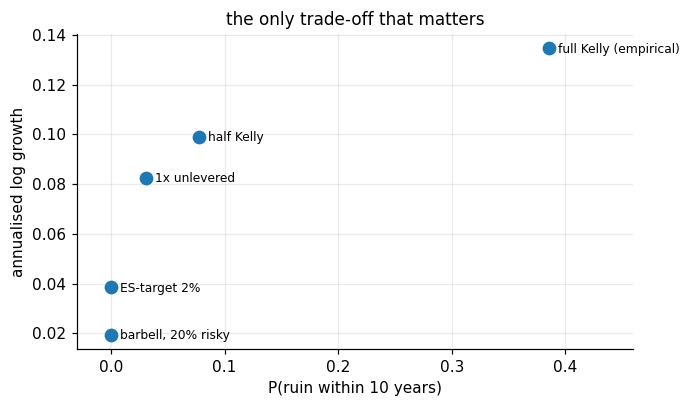

,ann. growth,ann. vol,ES99 (daily),median maxDD,"P(ruin, 10y)",growth per unit ruin
rule,,,,,,
full Kelly (empirical),0.1345,0.4902,0.1247,-0.8942,0.3859,0.3485
half Kelly,0.0991,0.2451,0.0623,-0.6044,0.0773,1.2822
1x unlevered,0.0825,0.1905,0.0485,-0.4989,0.0305,2.7068
ES-target 2%,0.0385,0.0786,0.0200,-0.2453,0.0000,385.1138
"barbell, 20% risky",0.0194,0.0381,0.0097,-0.1180,0.0000,194.3312


ensemble (arithmetic) mean return at full Kelly : 0.2874 /yr
time average (what a trajectory earns)          : 0.1436 /yr


In [ ]:
out = {}
for s in range(NS8):
    x = make("t(3)", T8, 100 + s)
    ks = kelly_empirical(x, fmax=60, grid=400)["f_star"]
    fes = leverage_for_es(x, 0.02, 0.01)
    for nm, y in (("full Kelly (empirical)", x * ks), ("half Kelly", x * ks * .5),
                  ("1x unlevered", x), ("ES-target 2%", x * fes),
                  ("barbell, 20% risky", barbell(x, 0.2))):
        w = simulate_wealth(y, 1., barrier=0.)
        out.setdefault(nm, []).append(
            (growth_rate(y, 1.) * 252, y.std() * np.sqrt(252), var_es_empirical(-y, .01)["es"],
             max_drawdown(w),
             ruin_probability(y, 1., 2520, reps=500, barrier=.5,
                              rng=np.random.default_rng(s))["p_ruin"]))
rows = []
for nm, v in out.items():
    v = np.array(v)
    rows.append({"rule": nm, "ann. growth": v[:, 0].mean(), "ann. vol": v[:, 1].mean(),
                 "ES99 (daily)": v[:, 2].mean(), "median maxDD": np.median(v[:, 3]),
                 "P(ruin, 10y)": v[:, 4].mean(),
                 "growth per unit ruin": v[:, 0].mean() / max(v[:, 4].mean(), 1e-4)})
sizing = pd.DataFrame(rows).set_index("rule")

x = make("t(3)", T8, 100); y = x * kelly_empirical(x, fmax=60, grid=400)["f_star"]
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(sizing["P(ruin, 10y)"], sizing["ann. growth"], "o", color=C0, ms=8)
for nm in sizing.index:
    ax.annotate(nm, (sizing.loc[nm, "P(ruin, 10y)"], sizing.loc[nm, "ann. growth"]),
                fontsize=8, xytext=(6, -3), textcoords="offset points")
ax.set(xlabel="P(ruin within 10 years)", ylabel="annualised log growth", xlim=(-0.03, 0.46))
plt.tight_layout(); plt.show()
display(sizing.round(4))
print(f"ensemble (arithmetic) mean return at full Kelly : {y.mean()*252:.4f} /yr")
print(f"time average (what a trajectory earns)          : {growth_rate(y,1.)*252:.4f} /yr")

The most important column of the table above is the **growth per unit ruin**. We see that full Kelly is $0.35$, half Kelly $1.28$, unlevered $2.71$,
barbell $194$, ES-target $385$. A monotone situation if you will.

Full Kelly maximises log growth, $13.5\%$ a year at a $39\%$ chance of losing half your capital within ten years and a median maximum drawdown of $-89\%$. Not fabolous. Half Kelly gives up a quarter of the growth for a fifth of the ruin. But the two rules that actually *target the tail* are in a different regime altogether. Indeed, the ES-target takes $3.5\times$ less growth than full Kelly and drops the ruin probability from $39\%$ to zero in $25 \times 500$ simulated decades.

The the ES-target annualised volatility is $7.9\%$ against the unlevered stream's $19.1\%$, so it is running about $0.41\times$, i.e., **it deleverages.** The rule "size so that your $1\%$ daily shortfall is $2\%$ of capital" independently arrives at less than full investment on a stream with $19\%$ annualised volatility. 

The scatter plot is of course a nice looking summary. There is a knee, and everything to the right of it is buying a small amount of growth with a large amount of ruin.

Finally, **the last two lines are the ergodicity point in its simplest form.** At full Kelly the arithmetic average return is $28.7\%$ a year. However, the log growth rate (i.e., what a single trajectory actually compounds at) is $14.4\%$. Exactly a factor of two. This follows because the arithmetic mean is an average *across* parallel worlds, including the ones where you were already broke and could not have participated. **You do not get the ensemble average. You get the time average, and only if you are still there.**

### The field checklist for the market notebook

We are back at a check list for when we are on the field. To wit:

**1. Never report a tail statistic without its sample size in the tail.** $\mathrm{ES}_{99}$ on 250
days is the mean of three numbers (Part 0). We must always look at $n_{\text{tail}}$ next to every tail number.

**2. Check moment existence before using a moment.** $R_n(4)$ and $\mathrm{MAD}/\mathrm{STD}$ first, kurtosis never on its own (Part 1). If $R_n(4)$ has not visibly decayed, no fourth-moment statistic really makes sense.

**3. Ask where the tail begins, not just what its exponent is.** Local exponent and mean-excess plots before any fit, and state the range over which the fit is claimed (Parts 2, 4).

**4. Never trust a single Hill plateau.** Cross-check Hill against Pickands, the moment estimator and the GPD fit. A disagreement between them *is* a result (Part 4).

**5. Report $\xi$, not $\alpha$, and put the interval on $\xi$.** $\alpha = 1/\xi$ manufactures a fat tail out of ordinary noise near $\xi = 0$ (Part 5).

**6. Use profile-likelihood intervals.** With fewer than a few hundred exceedances the Wald interval misses high three and a half times more often than advertised (Part 5).

**7. Treat every concentration and shortfall measure as a lower bound.** A meaningful share of both is structurally invisible at realistic sample sizes (Part 6).

**8. Score risk models on $Z_2$, not on exception counts.** A model can keep a respectable exception count while delivering two-thirds of the shortfall it promised (Part 7).

**9. Size on the tail, and check the wipeout leverage explicitly.** $\mu/\sigma^2$ cannot see the day that kills the portfolio. It is better to compute $-1/\min r$ and look at it (Part 8).

Onward to `narrative_evt_market_data.ipynb` to readers! There none of the answers shall be known and the five cleaned
portfolios of the previous lab are waiting to be re-scored on the tail.